In [32]:
import pandas as pd
df = pd.read_csv("SeoulBikeData.csv", encoding="latin-1")

In [113]:
x = df[df['Functioning Day'] == 'No']
x['Date'].value_counts()

2018-04-11    24
2018-05-10    24
2018-09-18    24
2018-09-19    24
2018-09-28    24
2018-09-30    24
2018-10-02    24
2018-10-04    24
2018-10-09    24
2018-11-03    24
2018-11-06    24
2018-11-09    24
2018-10-06     7
Name: Date, dtype: int64

In [91]:
df

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,DayOfWeek,Month,Year,Seasons_enc,Holiday_enc,FunctioningDay_enc
0,2017-12-01,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,4,12,2017,3,1,1
1,2017-12-01,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,4,12,2017,3,1,1
2,2017-12-01,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes,4,12,2017,3,1,1
3,2017-12-01,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,4,12,2017,3,1,1
4,2017-12-01,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes,4,12,2017,3,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8755,2018-11-30,1003,19,4.2,34,2.6,1894,-10.3,0.0,0.0,0.0,Autumn,No Holiday,Yes,4,11,2018,0,1,1
8756,2018-11-30,764,20,3.4,37,2.3,2000,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes,4,11,2018,0,1,1
8757,2018-11-30,694,21,2.6,39,0.3,1968,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes,4,11,2018,0,1,1
8758,2018-11-30,712,22,2.1,41,1.0,1859,-9.8,0.0,0.0,0.0,Autumn,No Holiday,Yes,4,11,2018,0,1,1


In [35]:
import statsmodels.api as sm

# Use the same X from before, just add a constant for the intercept
X_train_sm = sm.add_constant(X_train)

# Fit OLS
ols_model = sm.OLS(y_train, X_train_sm).fit()

# Print the full summary
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:      Rented Bike Count   R-squared:                       0.555
Model:                            OLS   Adj. R-squared:                  0.554
Method:                 Least Squares   F-statistic:                     581.8
Date:                Sun, 19 Apr 2026   Prob (F-statistic):               0.00
Time:                        20:17:20   Log-Likelihood:                -52440.
No. Observations:                7008   AIC:                         1.049e+05
Df Residuals:                    6992   BIC:                         1.050e+05
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

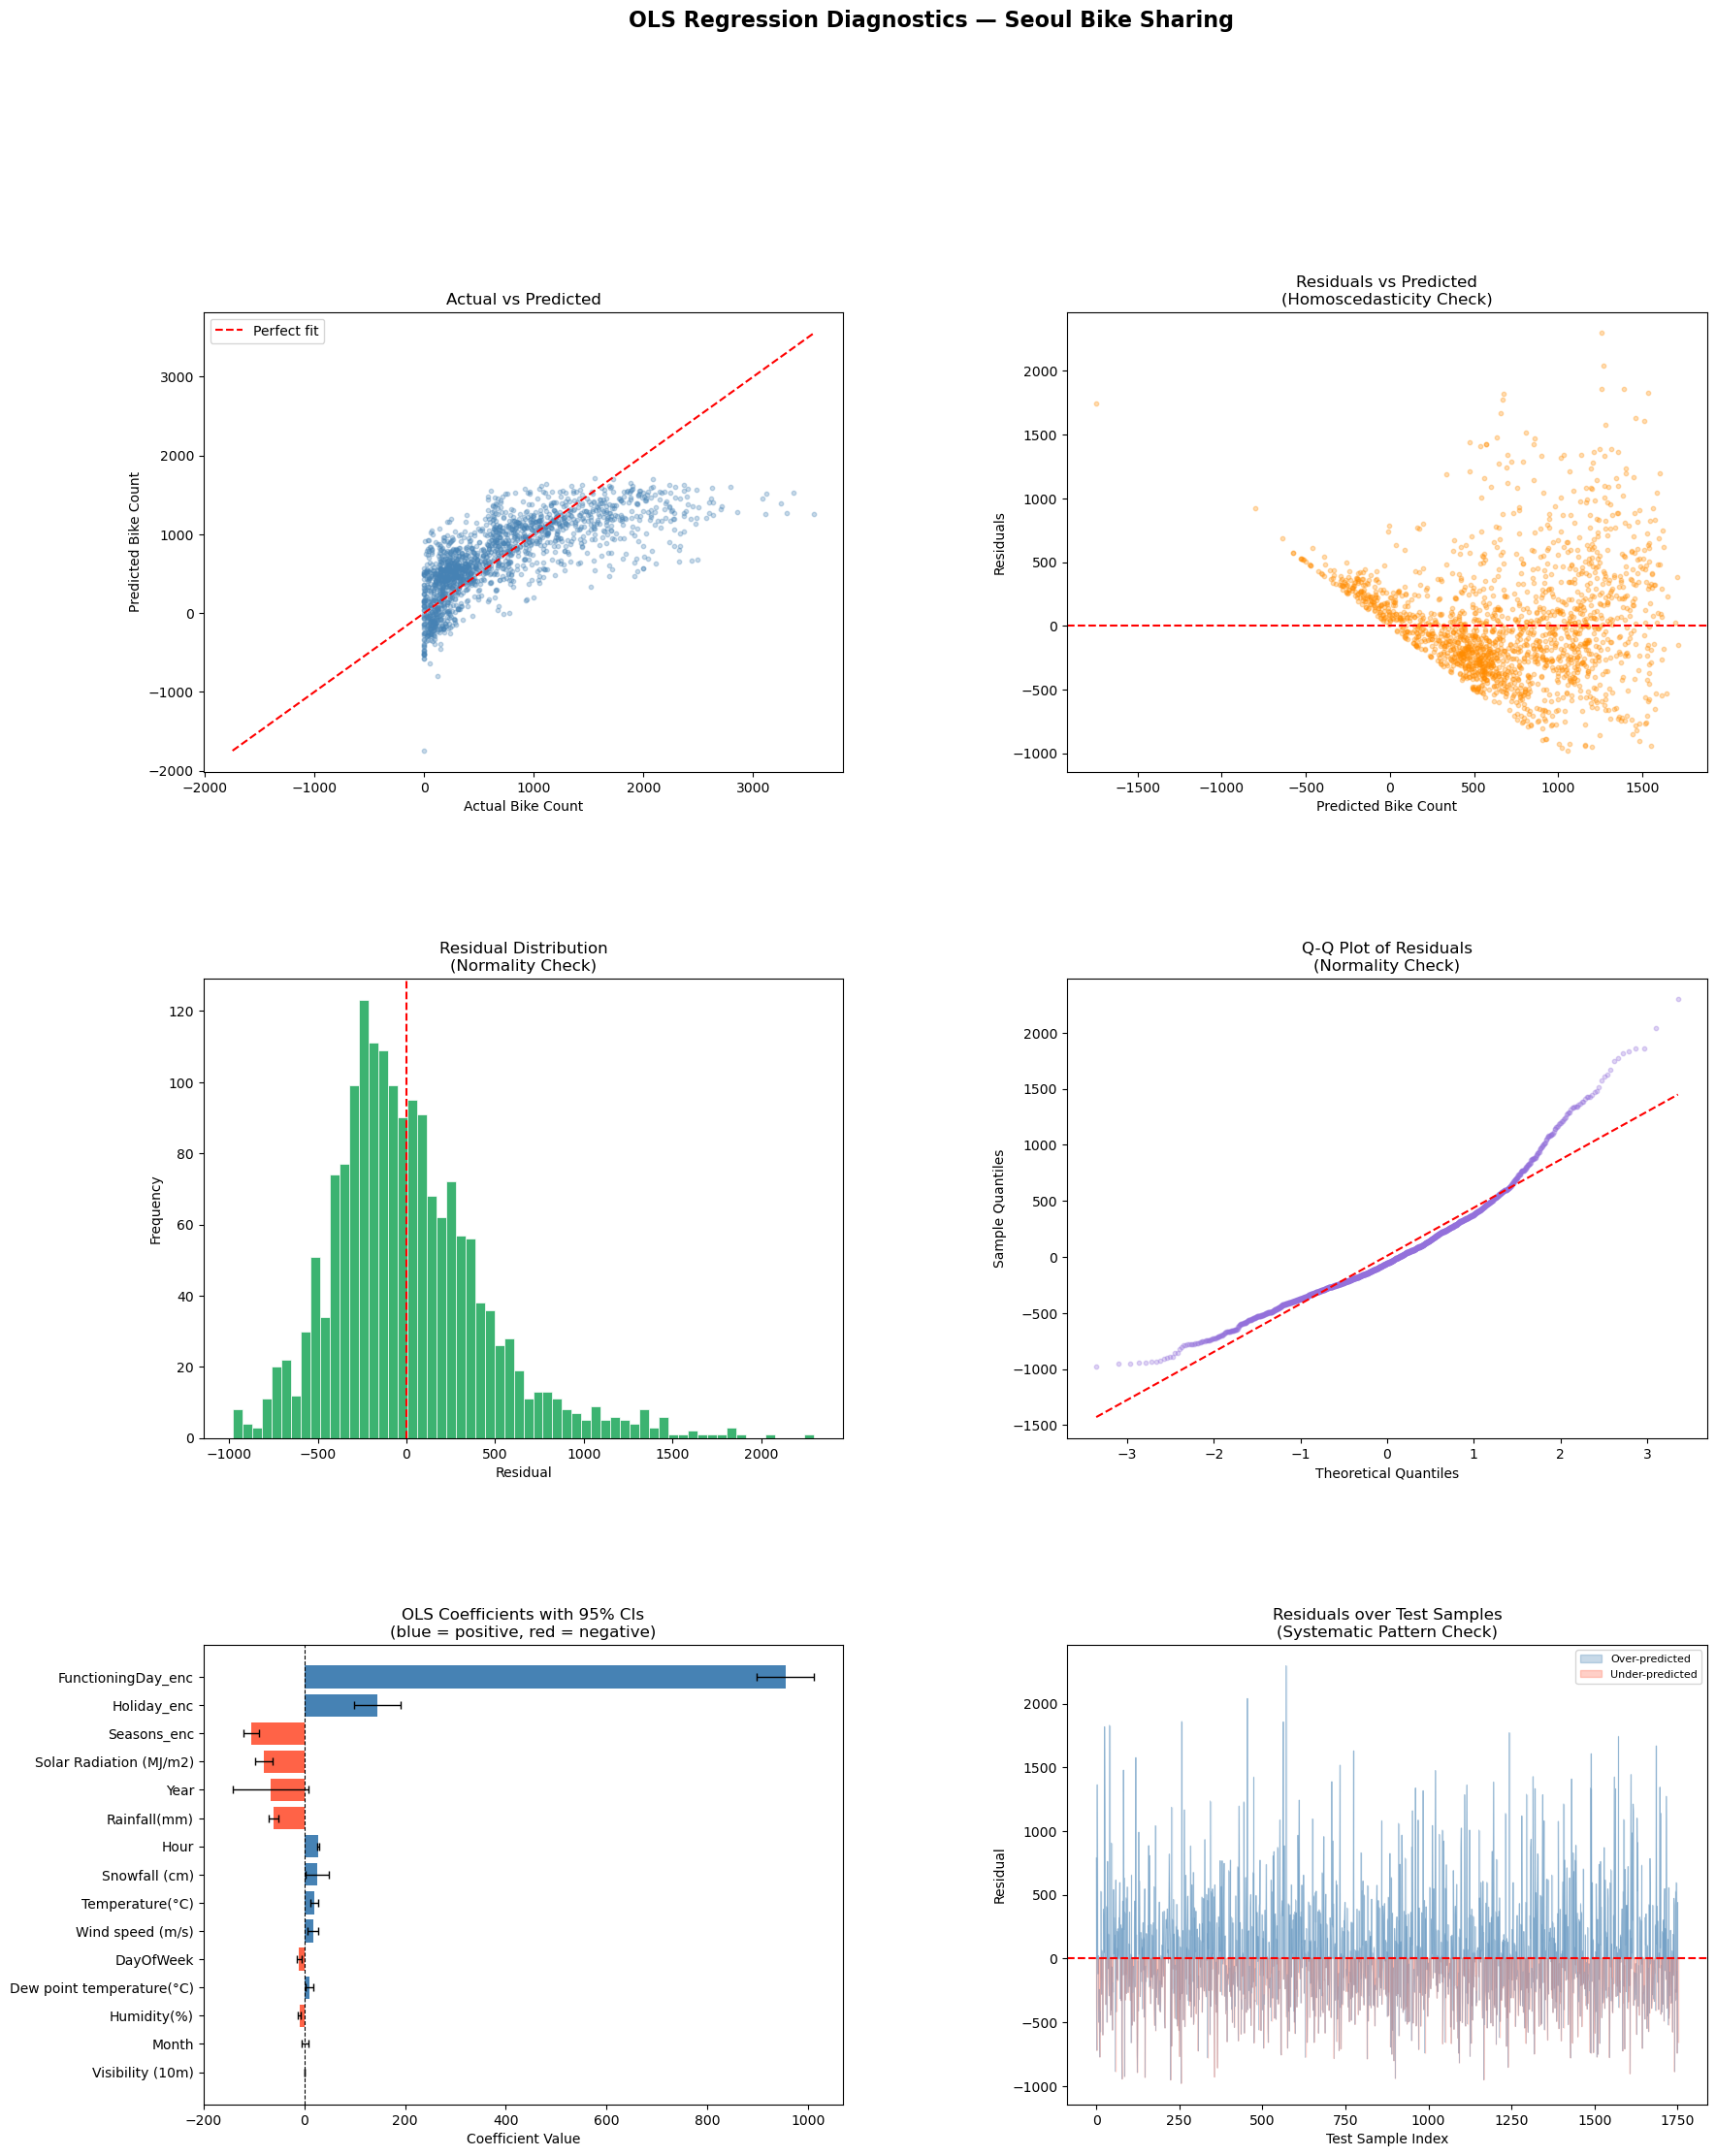

In [36]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np

# --- Get predictions and residuals on TEST set ---
X_test_sm = sm.add_constant(X_test)
y_pred_sm  = ols_model.predict(X_test_sm)
residuals  = y_test - y_pred_sm

fig = plt.figure(figsize=(20, 24))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

# ── 1. Actual vs Predicted ──────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(y_test, y_pred_sm, alpha=0.3, color='steelblue', s=10)
lims = [min(y_test.min(), y_pred_sm.min()), max(y_test.max(), y_pred_sm.max())]
ax1.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect fit')
ax1.set_xlabel('Actual Bike Count')
ax1.set_ylabel('Predicted Bike Count')
ax1.set_title('Actual vs Predicted')
ax1.legend()

# ── 2. Residuals vs Predicted (Homoscedasticity check) ─────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.scatter(y_pred_sm, residuals, alpha=0.3, color='darkorange', s=10)
ax2.axhline(0, color='red', linestyle='--', linewidth=1.5)
ax2.set_xlabel('Predicted Bike Count')
ax2.set_ylabel('Residuals')
ax2.set_title('Residuals vs Predicted\n(Homoscedasticity Check)')

# ── 3. Residual Distribution ────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
ax3.hist(residuals, bins=60, color='mediumseagreen', edgecolor='white', linewidth=0.5)
ax3.axvline(0, color='red', linestyle='--', linewidth=1.5)
ax3.set_xlabel('Residual')
ax3.set_ylabel('Frequency')
ax3.set_title('Residual Distribution\n(Normality Check)')

# ── 4. Q-Q Plot ─────────────────────────────────────────────────────────────
from scipy import stats
ax4 = fig.add_subplot(gs[1, 1])
(osm, osr), (slope, intercept, r) = stats.probplot(residuals, dist='norm')
ax4.scatter(osm, osr, alpha=0.3, color='mediumpurple', s=10)
ax4.plot(osm, slope * np.array(osm) + intercept, 'r--', linewidth=1.5)
ax4.set_xlabel('Theoretical Quantiles')
ax4.set_ylabel('Sample Quantiles')
ax4.set_title(f'Q-Q Plot of Residuals\n(Normality Check)')

# ── 5. Top Feature Coefficients (with confidence intervals) ─────────────────
ax5 = fig.add_subplot(gs[2, 0])
coef_summary = ols_model.summary2().tables[1].drop('const', errors='ignore')
coef_summary = coef_summary.reindex(
    coef_summary['Coef.'].abs().sort_values(ascending=True).index
)
colors = ['tomato' if c < 0 else 'steelblue' for c in coef_summary['Coef.']]
ax5.barh(coef_summary.index, coef_summary['Coef.'], color=colors,
         xerr=(coef_summary['Coef.'] - coef_summary['[0.025']).abs(),
         capsize=3, error_kw={'linewidth': 1})
ax5.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax5.set_xlabel('Coefficient Value')
ax5.set_title('OLS Coefficients with 95% CIs\n(blue = positive, red = negative)')

# ── 6. Residuals over Time ──────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[2, 1])
ax6.plot(np.arange(len(residuals)), residuals.values, alpha=0.4,
         color='steelblue', linewidth=0.5)
ax6.axhline(0, color='red', linestyle='--', linewidth=1.5)
ax6.fill_between(np.arange(len(residuals)), residuals.values, 0,
                 where=(residuals.values > 0), alpha=0.3, color='steelblue',
                 label='Over-predicted')
ax6.fill_between(np.arange(len(residuals)), residuals.values, 0,
                 where=(residuals.values < 0), alpha=0.3, color='tomato',
                 label='Under-predicted')
ax6.set_xlabel('Test Sample Index')
ax6.set_ylabel('Residual')
ax6.set_title('Residuals over Test Samples\n(Systematic Pattern Check)')
ax6.legend(fontsize=8)

plt.suptitle('OLS Regression Diagnostics — Seoul Bike Sharing', 
             fontsize=16, fontweight='bold', y=1.01)
plt.savefig('ols_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

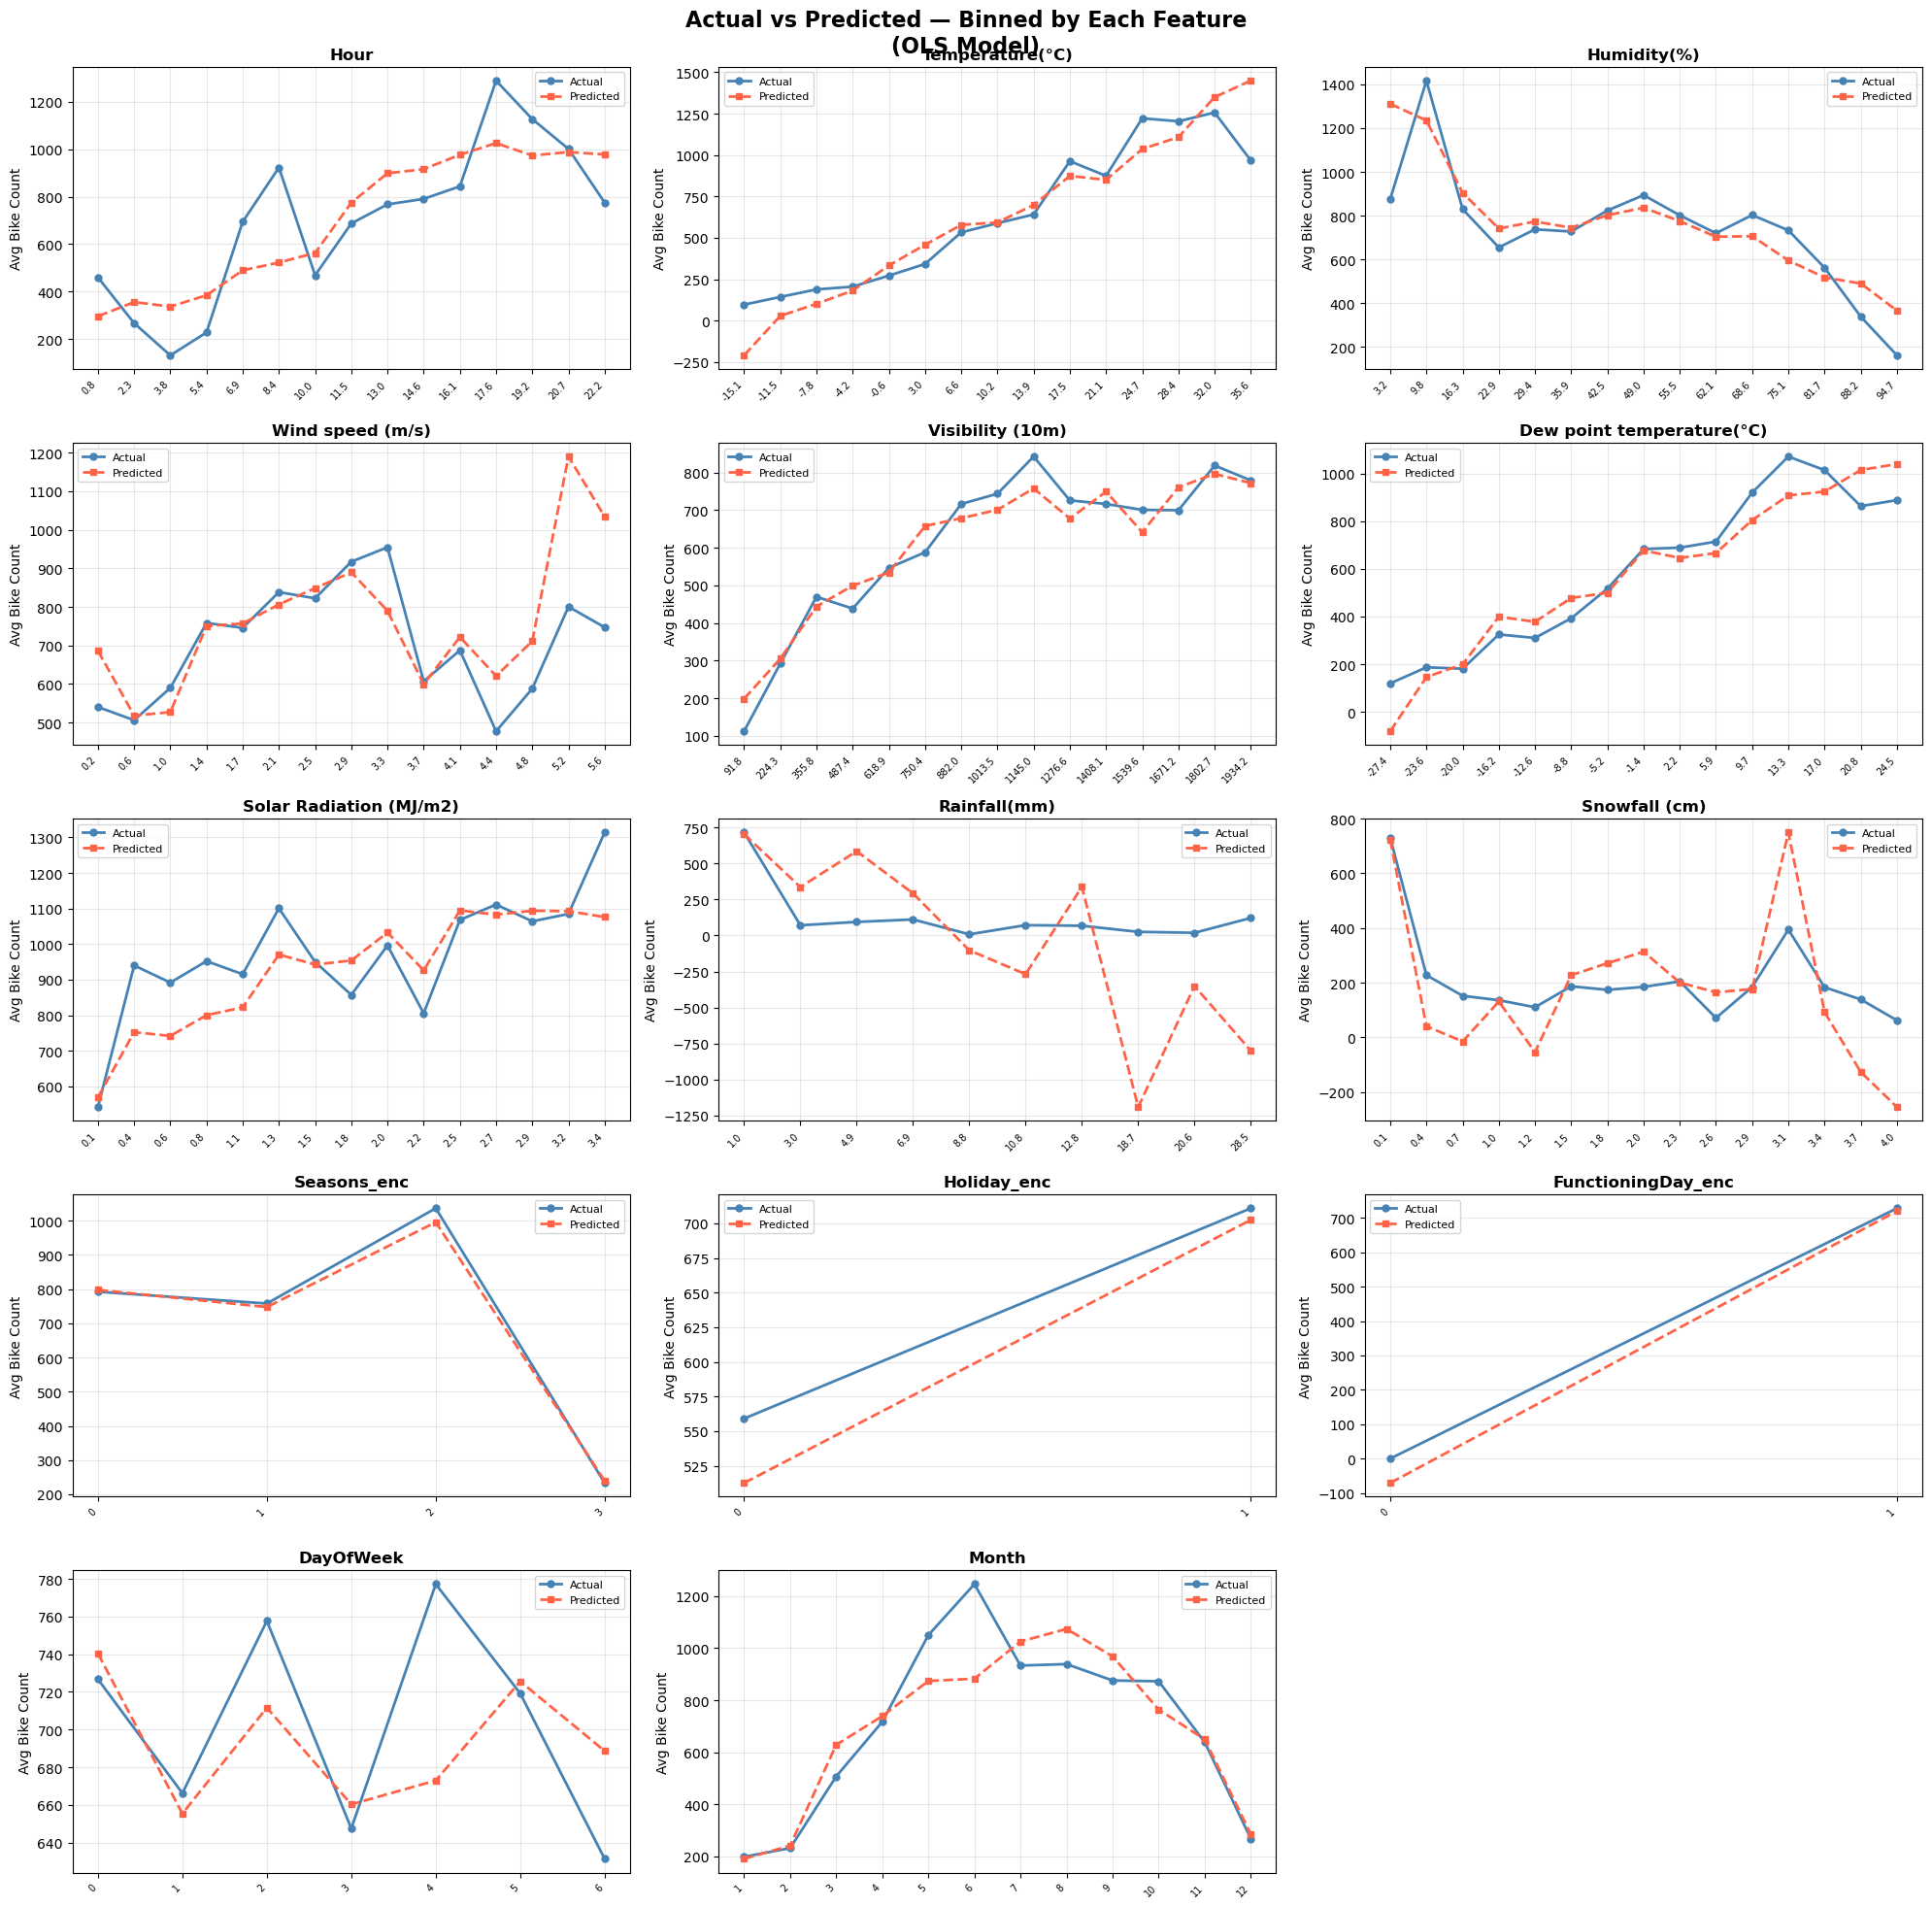

In [38]:
# ── Option 2: Actual vs Predicted binned by each feature ────────────────────
# More intuitive for presentations — shows where the model tracks well
# and where it diverges, across the range of each variable

features_to_plot = [
    'Hour', 'Temperature(°C)', 'Humidity(%)', 'Wind speed (m/s)',
    'Visibility (10m)', 'Dew point temperature(°C)',
    'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)',
    'Seasons_enc', 'Holiday_enc', 'FunctioningDay_enc',
    'DayOfWeek', 'Month'
]

n_cols = 3
n_rows = int(np.ceil(len(features_to_plot) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

# Reconstruct a test dataframe with predictions and actuals
plot_df = X_test.copy()
plot_df['Actual']    = y_test.values
plot_df['Predicted'] = y_pred_sm.values

for i, feat in enumerate(features_to_plot):
    ax = axes[i]

    # Bin continuous features into 15 buckets; keep categoricals as-is
    n_unique = plot_df[feat].nunique()
    if n_unique > 15:
        plot_df['_bin'] = pd.cut(plot_df[feat], bins=15)
    else:
        plot_df['_bin'] = plot_df[feat]

    binned = (plot_df.groupby('_bin', observed=True)[['Actual', 'Predicted']]
                     .mean()
                     .reset_index()
                     .sort_values('_bin'))

    ax.plot(binned.index, binned['Actual'],    'o-', color='steelblue',
            linewidth=2, markersize=5, label='Actual')
    ax.plot(binned.index, binned['Predicted'], 's--', color='tomato',
            linewidth=2, markersize=5, label='Predicted')

    # Use readable tick labels
    ax.set_xticks(binned.index)
    labels = [str(b) if n_unique <= 15 else 
              f"{b.mid:.1f}" for b in binned['_bin']]
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=7)

    ax.set_title(feat, fontweight='bold')
    ax.set_ylabel('Avg Bike Count')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Actual vs Predicted — Binned by Each Feature\n(OLS Model)', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('actual_vs_predicted_by_feature.png', dpi=150, bbox_inches='tight')
plt.show()

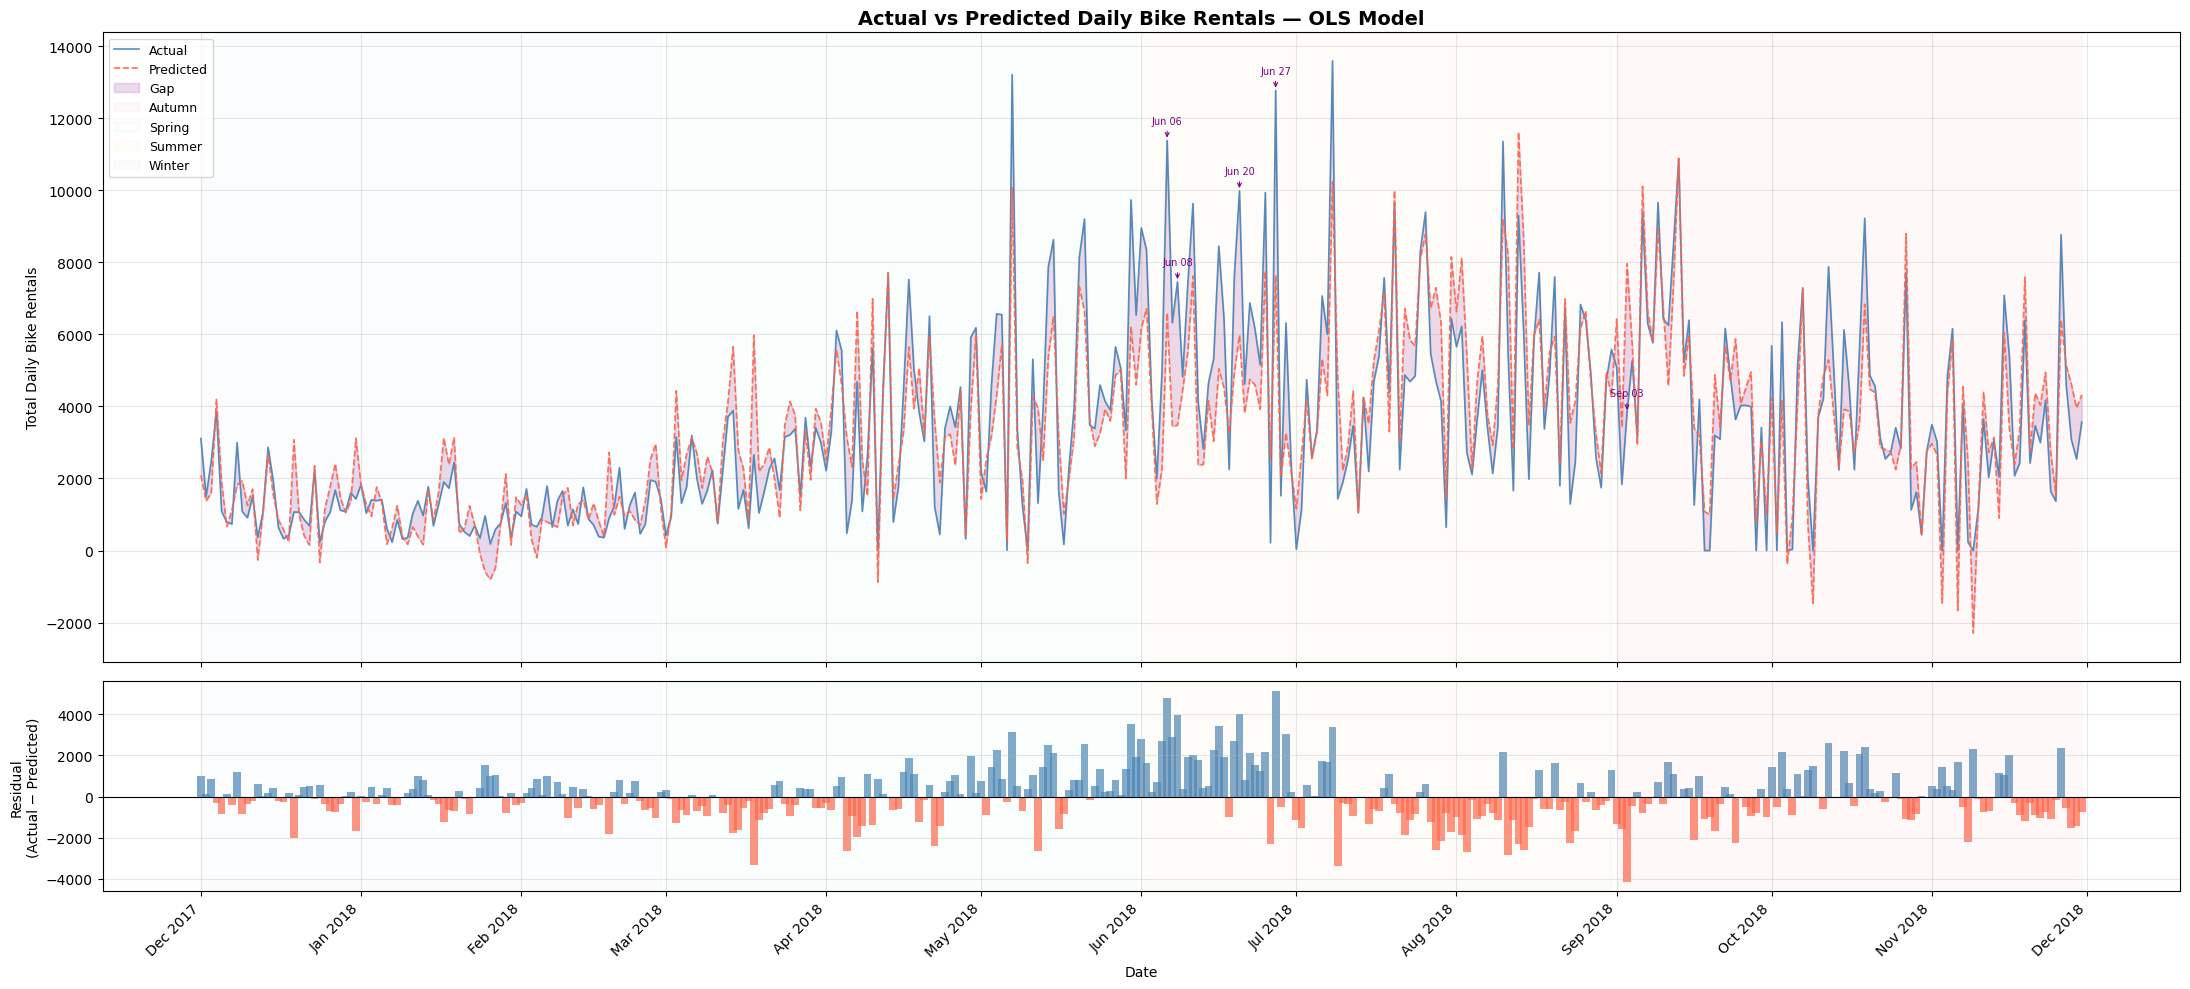

In [39]:
# ── Actual vs Predicted across Date ─────────────────────────────────────────

# Reconstruct daily totals from test set
plot_df = X_test.copy()
plot_df['Date']      = df.loc[X_test.index, 'Date']
plot_df['Actual']    = y_test.values
plot_df['Predicted'] = y_pred_sm.values

# Aggregate to daily totals
daily = (plot_df.groupby('Date')[['Actual', 'Predicted']]
                .sum()
                .reset_index()
                .sort_values('Date'))

fig, axes = plt.subplots(2, 1, figsize=(22, 10), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1]})

# ── Top: Actual vs Predicted line plot ──────────────────────────────────────
axes[0].plot(daily['Date'], daily['Actual'],    color='steelblue',
             linewidth=1.2, label='Actual', alpha=0.9)
axes[0].plot(daily['Date'], daily['Predicted'], color='tomato',
             linewidth=1.2, linestyle='--', label='Predicted', alpha=0.9)
axes[0].fill_between(daily['Date'], daily['Actual'], daily['Predicted'],
                     alpha=0.15, color='purple', label='Gap')
axes[0].set_ylabel('Total Daily Bike Rentals')
axes[0].set_title('Actual vs Predicted Daily Bike Rentals — OLS Model',
                  fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# Annotate worst prediction days
daily['Error'] = (daily['Actual'] - daily['Predicted']).abs()
worst = daily.nlargest(5, 'Error')
for _, row in worst.iterrows():
    axes[0].annotate(f"{row['Date'].strftime('%b %d')}",
                     xy=(row['Date'], row['Actual']),
                     xytext=(0, 12), textcoords='offset points',
                     fontsize=7, color='purple', ha='center',
                     arrowprops=dict(arrowstyle='->', color='purple', lw=0.8))

# ── Bottom: Daily residual (error) bar chart ─────────────────────────────────
daily['Residual'] = daily['Actual'] - daily['Predicted']
colors = ['steelblue' if r >= 0 else 'tomato' for r in daily['Residual']]
axes[1].bar(daily['Date'], daily['Residual'], color=colors,
            width=1.5, alpha=0.7)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_ylabel('Residual\n(Actual − Predicted)')
axes[1].set_xlabel('Date')
axes[1].grid(alpha=0.3)

# Add season shading on both axes
season_colors = {'Winter': '#AED6F1', 'Spring': '#A9DFBF',
                 'Summer': '#FAD7A0', 'Autumn': '#F1948A'}
season_df = df[['Date', 'Seasons']].drop_duplicates().sort_values('Date')
for season, grp in season_df.groupby('Seasons'):
    s, e = grp['Date'].min(), grp['Date'].max()
    for ax in axes:
        ax.axvspan(s, e, alpha=0.06, color=season_colors.get(season, 'grey'),
                   label=season)

# Clean up season legend (deduplicate)
handles, labels = axes[0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
axes[0].legend(by_label.values(), by_label.keys(), fontsize=9, loc='upper left')

import matplotlib.dates as mdates
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[1].xaxis.set_major_locator(mdates.MonthLocator())
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig('actual_vs_predicted_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

In [42]:
# Cell 1 — Build interactions
X_train_int = build_interactions(X_train, continuous, categorical)
X_test_int  = build_interactions(X_test,  continuous, categorical)

print(f"Original features : {X_train.shape[1]}")
print(f"With interactions : {X_train_int.shape[1]}")

Original features : 15
With interactions : 131


/var/folders/t5/79mxhlcx5qj369sxm8k2vs_w0000gq/T/ipykernel_16170/3360337914.py:26: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_out[f'{c1} × {c2}'] = X[c1] * X[c2]
/var/folders/t5/79mxhlcx5qj369sxm8k2vs_w0000gq/T/ipykernel_16170/3360337914.py:26: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_out[f'{c1} × {c2}'] = X[c1] * X[c2]
/var/folders/t5/79mxhlcx5qj369sxm8k2vs_w0000gq/T/ipykernel_16170/3360337914.py:26: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many time

In [43]:
# Cell 2 — Scale
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_int)
X_test_scaled  = scaler.transform(X_test_int)

In [44]:
# Cell 3 — Fit LassoCV
from sklearn.linear_model import LassoCV

lasso = LassoCV(cv=5, random_state=42, max_iter=10000, n_jobs=-1)
lasso.fit(X_train_scaled, y_train)

print(f"Best alpha (λ): {lasso.alpha_:.4f}")

Best alpha (λ): 0.4351


In [45]:
# Cell 4 — Identify survivors
feature_names = X_train_int.columns.tolist()
coef_series   = pd.Series(lasso.coef_, index=feature_names)
survivors     = coef_series[coef_series != 0].index.tolist()

print(f"Total features  : {len(feature_names)}")
print(f"Survivors (≠ 0) : {len(survivors)}")
print(f"Zeroed out      : {len(feature_names) - len(survivors)}")

Total features  : 131
Survivors (≠ 0) : 88
Zeroed out      : 43


In [46]:
# Cell 5 — Inspect surviving coefficients
coef_series[survivors].sort_values(key=abs, ascending=False)

Month × Year                                 816.574358
Month^2                                     -781.949095
Humidity(%) × Year                           479.853848
Temperature(°C) × FunctioningDay_enc         429.891003
Humidity(%)^2                               -345.595902
                                                ...    
Dew point temperature(°C) × Snowfall (cm)     -1.772020
Holiday_enc                                   -1.693247
Holiday_enc × FunctioningDay_enc               1.690524
Dew point temperature(°C) × DayOfWeek         -1.113065
Seasons_enc                                    0.525592
Length: 88, dtype: float64

In [47]:
# Cell 6 — Refit OLS on survivors
X_train_survivors = sm.add_constant(X_train_int[survivors])
X_test_survivors  = sm.add_constant(X_test_int[survivors])

ols_lasso_model = sm.OLS(y_train, X_train_survivors).fit()
y_pred_lasso    = ols_lasso_model.predict(X_test_survivors)

ols_lasso_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      Rented Bike Count   R-squared:                       0.711
Model:                            OLS   Adj. R-squared:                  0.708
Method:                 Least Squares   F-statistic:                     198.4
Date:                Sun, 19 Apr 2026   Prob (F-statistic):               0.00
Time:                        20:31:50   Log-Likelihood:                -50924.
No. Observations:                7008   AIC:                         1.020e+05
Df Residuals:                    6921   BIC:                         1.026e+05
Df Model:                          86                                         
Covariance Type:            nonrobust                                         
=======================================================================================================================
                                                          coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------------
const                                                1.107e+04   3008.844      3.678      0.000    5167.263     1.7e+04
Humidity(%)                                         -9990.4520   3258.350     -3.066      0.002   -1.64e+04   -3603.086
Wind speed (m/s)                                      189.1663     34.044      5.557      0.000     122.430     255.903
Seasons_enc                                           3.32e+04   9026.533      3.678      0.000    1.55e+04    5.09e+04
Holiday_enc                                         -7.228e+04   1.28e+05     -0.564      0.573   -3.23e+05    1.79e+05
Month                                                1.328e+05   3.61e+04      3.678      0.000     6.2e+04    2.04e+05
Year                                                   -6.4979      1.510     -4.303      0.000      -9.458      -3.538
Humidity(%)^2                                          -0.1521      0.019     -8.213      0.000      -0.188      -0.116
Wind speed (m/s)^2                                    -21.0416      3.250     -6.474      0.000     -27.413     -14.670
Visibility (10m)^2                                  -1.709e-05    1.5e-05     -1.142      0.253   -4.64e-05    1.22e-05
Dew point temperature(°C)^2                            -0.1725      0.072     -2.400      0.016      -0.313      -0.032
Solar Radiation (MJ/m2)^2                             -38.1610      8.724     -4.374      0.000     -55.263     -21.059
Rainfall(mm)^2                                          5.0862      0.540      9.417      0.000       4.027       6.145
Snowfall (cm)^2                                        -8.0130      5.665     -1.415      0.157     -19.118       3.092
DayOfWeek^2                                           -10.3870      1.268     -8.191      0.000     -12.873      -7.901
Month^2                                               -25.4359      1.857    -13.699      0.000     -29.076     -21.796
Hour × Temperature(°C)                                  1.1448      0.242      4.737      0.000       0.671       1.619
Hour × Humidity(%)                                     -0.6642      0.058    -11.538      0.000      -0.777      -0.551
Hour × Wind speed (m/s)                                 1.4309      0.749      1.911      0.056      -0.037       2.898
Hour × Visibility (10m)                                 0.0016      0.001      1.309      0.190      -0.001       0.004
Hour × Dew point temperature(°C)                        0.6476      0.242      2.681      0.007       0.174       1.121
Hour × Solar Radiation (MJ/m2)                         11.3252      2.426      4.668      0.000       6.569      16.082
Hour × Rainfall(mm)                                    -3.4524      0.865     -3.99

In [48]:
# Cell 7 — Model comparison
from sklearn.metrics import r2_score, mean_squared_error

metrics = pd.DataFrame({
    'Model': ['OLS (base)', 'OLS (Lasso survivors)'],
    'R²':    [r2_score(y_test, y_pred_sm),    r2_score(y_test, y_pred_lasso)],
    'RMSE':  [np.sqrt(mean_squared_error(y_test, y_pred_sm)),
              np.sqrt(mean_squared_error(y_test, y_pred_lasso))],
    'AIC':   [ols_model.aic,       ols_lasso_model.aic],
    'BIC':   [ols_model.bic,       ols_lasso_model.bic],
}).set_index('Model').round(3)

metrics

,R²,RMSE,AIC,BIC
Model,,,,
OLS (base),0.534,440.476,104911.868,105021.545
OLS (Lasso survivors),0.666,373.126,102021.723,102618.091


In [50]:
# Cell 1 — Forward selection function
import statsmodels.api as sm

def forward_selection(X, y, metric='aic'):
    remaining   = list(X.columns)
    selected    = []
    current_score = np.inf

    while remaining:
        scores = {}
        for candidate in remaining:
            cols  = selected + [candidate]
            model = sm.OLS(y, sm.add_constant(X[cols])).fit()
            scores[candidate] = getattr(model, metric)

        best_feature = min(scores, key=scores.get)
        best_score   = scores[best_feature]

        if best_score < current_score:
            selected.append(best_feature)
            remaining.remove(best_feature)
            current_score = best_score
            print(f"+ {best_feature:<45} {metric.upper()}: {best_score:.2f}")
        else:
            print(f"\nNo improvement. Stopping.")
            break

    return selected, current_score

In [51]:
# Cell 2 — Run on base features
selected_base, final_score = forward_selection(X_train, y_train, metric='aic')

print(f"\nSelected {len(selected_base)} features")
print(f"Final AIC: {final_score:.2f}")

+ Temperature(°C)                               AIC: 108176.15
+ Hour                                          AIC: 106822.00
+ FunctioningDay_enc                            AIC: 106163.15
+ Humidity(%)                                   AIC: 105631.25
+ Seasons_enc                                   AIC: 105260.63
+ Rainfall(mm)                                  AIC: 105095.35
+ Solar Radiation (MJ/m2)                       AIC: 104984.82
+ Holiday_enc                                   AIC: 104955.97
+ DayOfWeek                                     AIC: 104938.68
+ Year                                          AIC: 104926.66
+ Wind speed (m/s)                              AIC: 104919.28
+ Dew point temperature(°C)                     AIC: 104915.01
+ Snowfall (cm)                                 AIC: 104912.47
+ Visibility (10m)                              AIC: 104910.04

No improvement. Stopping.

Selected 14 features
Final AIC: 104910.04


In [60]:
# Cell 3 — (Optional) Run on interaction features instead
# Slower — ~120 features to search through
# Uncomment if you want to run it on the full interaction set

selected_int, final_score_int = forward_selection(X_train_int, y_train, metric='bic')

+ Hour × Temperature(°C)                        BIC: 106316.47
+ Visibility (10m) × FunctioningDay_enc         BIC: 105601.55
+ Dew point temperature(°C)^2                   BIC: 105222.22
+ FunctioningDay_enc × Year                     BIC: 104857.10
+ Humidity(%)^2                                 BIC: 104659.76
+ Visibility (10m) × Seasons_enc                BIC: 104442.19
+ Solar Radiation (MJ/m2)^2                     BIC: 104272.43
+ Temperature(°C) × FunctioningDay_enc          BIC: 104128.46
+ Hour × Visibility (10m)                       BIC: 104005.49
+ Hour × Rainfall(mm)                           BIC: 103894.26
+ Temperature(°C) × Seasons_enc                 BIC: 103807.07
+ Dew point temperature(°C) × Seasons_enc       BIC: 103738.13
+ Temperature(°C)                               BIC: 103663.34
+ Dew point temperature(°C) × Solar Radiation (MJ/m2) BIC: 103609.02
+ Humidity(%) × Solar Radiation (MJ/m2)         BIC: 103538.92
+ Rainfall(mm)^2                                B

In [61]:
# Cell 4 — Refit final OLS on selected interaction features
X_train_fwd = sm.add_constant(X_train_int[selected_int])
X_test_fwd  = sm.add_constant(X_test_int[selected_int])

ols_fwd_model = sm.OLS(y_train, X_train_fwd).fit()
y_pred_fwd    = ols_fwd_model.predict(X_test_fwd)

ols_fwd_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      Rented Bike Count   R-squared:                       0.710
Model:                            OLS   Adj. R-squared:                  0.707
Method:                 Least Squares   F-statistic:                     320.6
Date:                Sun, 19 Apr 2026   Prob (F-statistic):               0.00
Time:                        20:44:21   Log-Likelihood:                -50946.
No. Observations:                7008   AIC:                         1.020e+05
Df Residuals:                    6954   BIC:                         1.024e+05
Df Model:                          53                                         
Covariance Type:            nonrobust                                         
=======================================================================================================================
                                                          coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------------
const                                               -3090.3288    246.040    -12.560      0.000   -3572.643   -2608.015
Hour × Temperature(°C)                                  1.7149      0.068     25.097      0.000       1.581       1.849
Visibility (10m) × FunctioningDay_enc                  -0.0128      0.038     -0.339      0.735      -0.087       0.061
Dew point temperature(°C)^2                            -0.0175      0.073     -0.239      0.811      -0.161       0.126
FunctioningDay_enc × Year                               0.4445      0.121      3.678      0.000       0.208       0.681
Humidity(%)^2                                          -0.2113      0.015    -14.563      0.000      -0.240      -0.183
Visibility (10m) × Seasons_enc                          0.0328      0.009      3.555      0.000       0.015       0.051
Solar Radiation (MJ/m2)^2                             -30.8027      7.038     -4.377      0.000     -44.599     -17.006
Temperature(°C) × FunctioningDay_enc                   39.2070      6.367      6.158      0.000      26.725      51.689
Hour × Visibility (10m)                                 0.0022      0.001      2.148      0.032       0.000       0.004
Hour × Rainfall(mm)                                    -3.6722      0.837     -4.388      0.000      -5.313      -2.031
Temperature(°C) × Seasons_enc                         -20.8866      2.950     -7.079      0.000     -26.670     -15.103
Dew point temperature(°C) × Seasons_enc                11.9169      3.121      3.818      0.000       5.799      18.035
Temperature(°C)                                       6.84e+04      1e+04      6.825      0.000    4.88e+04    8.81e+04
Dew point temperature(°C) × Solar Radiation (MJ/m2)   -10.2252      0.776    -13.182      0.000     -11.746      -8.705
Humidity(%) × Solar Radiation (MJ/m2)                   6.4968      0.557     11.654      0.000       5.404       7.590
Rainfall(mm)^2                                          4.2561      0.476      8.944      0.000       3.323       5.189
Visibility (10m) × Holiday_enc                          0.0794      0.019      4.231      0.000       0.043       0.116
Hour × Humidity(%)                                     -0.4882      0.039    -12.394      0.000      -0.565      -0.411
Hour × FunctioningDay_enc                              38.4235      3.337     11.515      0.000      31.882      44.965
Humidity(%)                                            42.1559      2.835     14.867      0.000      36.598      47.714
Visibility (10m) × Dew point temperature(°C)            0.0001      0.001      0.118      0.906      -0.002       0.002
DayOfWeek^2                                            -9.9420      1.245     -7.98

In [62]:
# Cell 5 — Updated model comparison
metrics = pd.DataFrame({
    'Model': ['OLS (base)', 'OLS (Lasso survivors)', 'OLS (Forward selection on interactions)'],
    'R²':    [r2_score(y_test, y_pred_sm),
              r2_score(y_test, y_pred_lasso),
              r2_score(y_test, y_pred_fwd)],
    'RMSE':  [np.sqrt(mean_squared_error(y_test, y_pred_sm)),
              np.sqrt(mean_squared_error(y_test, y_pred_lasso)),
              np.sqrt(mean_squared_error(y_test, y_pred_fwd))],
    'AIC':   [ols_model.aic, ols_lasso_model.aic, ols_fwd_model.aic],
    'BIC':   [ols_model.bic, ols_lasso_model.bic, ols_fwd_model.bic],
    'N Features': [X_train.shape[1], len(survivors), len(selected_int)]
}).set_index('Model').round(3)

metrics

,R²,RMSE,AIC,BIC,N Features
Model,,,,,
OLS (base),0.534,440.476,104911.868,105021.545,15
OLS (Lasso survivors),0.666,373.126,102021.723,102618.091,88
OLS (Forward selection on interactions),0.676,367.428,102000.664,102370.824,53


In [75]:
# Cell 1 — Define simple model features
simple_features = [
    'Hour',
    'Temperature(°C)',
    'Seasons_enc',
    'Holiday_enc',
    'DayOfWeek'
]

X_train_simple = sm.add_constant(X_train[simple_features])
X_test_simple  = sm.add_constant(X_test[simple_features])

In [76]:
# Cell 2 — Fit simple OLS
ols_simple = sm.OLS(y_train, X_train_simple).fit()
y_pred_simple = ols_simple.predict(X_test_simple)

ols_simple.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      Rented Bike Count   R-squared:                       0.426
Model:                            OLS   Adj. R-squared:                  0.425
Method:                 Least Squares   F-statistic:                     1038.
Date:                Sun, 19 Apr 2026   Prob (F-statistic):               0.00
Time:                        21:00:13   Log-Likelihood:                -53335.
No. Observations:                7008   AIC:                         1.067e+05
Df Residuals:                    7002   BIC:                         1.067e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const             -22.8677     31.175     -0.734      0.463     -83.980      38.245
Hour               33.6840      0.853     39.480      0.000      32.011      35.357
Temperature(°C)    24.7290      0.526     47.002      0.000      23.698      25.760
Seasons_enc       -57.3095      5.574    -10.282      0.000     -68.236     -46.383
Holiday_enc       141.9372     26.818      5.293      0.000      89.365     194.509
DayOfWeek          -9.7758      2.932     -3.334      0.001     -15.524      -4.028
==============================================================================
Omnibus:                      560.183   Durbin-Watson:                   2.028
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1015.128
Skew:                           0.571   Prob(JB):                    3.70e-221
Kurtosis:                       4.474   Cond. No.                         138.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [77]:
# Cell 3 — Coefficients with CIs (clean table for interpretation)
ci = ols_simple.conf_int()
ci.columns = ['CI 2.5%', 'CI 97.5%']

coef_table = pd.DataFrame({
    'Coefficient': ols_simple.params,
    'Std Error':   ols_simple.bse,
    'p-value':     ols_simple.pvalues,
    'CI 2.5%':     ci['CI 2.5%'],
    'CI 97.5%':    ci['CI 97.5%']
}).drop('const').round(4)

coef_table

,Coefficient,Std Error,p-value,CI 2.5%,CI 97.5%
Hour,33.6840,0.8532,0.0000,32.0115,35.3565
Temperature(°C),24.7290,0.5261,0.0000,23.6976,25.7603
Seasons_enc,-57.3095,5.5738,0.0000,-68.2357,-46.3832
Holiday_enc,141.9372,26.8184,0.0000,89.3651,194.5094
DayOfWeek,-9.7758,2.9321,0.0009,-15.5235,-4.0280


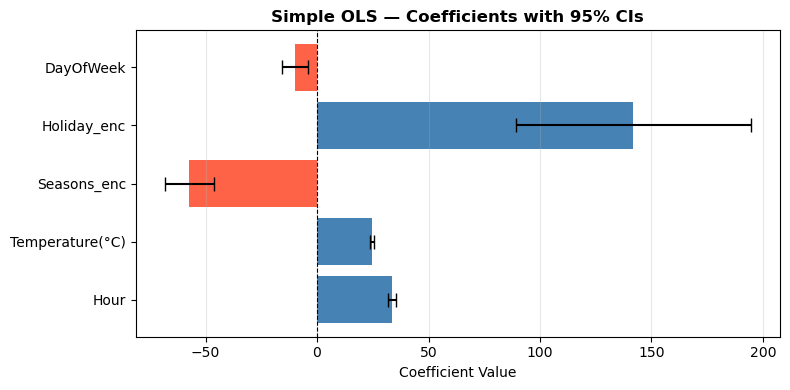

In [78]:
# Cell 4 — Visualise coefficients with CIs
fig, ax = plt.subplots(figsize=(8, 4))

ax.barh(coef_table.index, coef_table['Coefficient'],
        xerr=[coef_table['Coefficient'] - coef_table['CI 2.5%'],
              coef_table['CI 97.5%'] - coef_table['Coefficient']],
        color=['steelblue' if c > 0 else 'tomato' for c in coef_table['Coefficient']],
        capsize=5)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Coefficient Value')
ax.set_title('Simple OLS — Coefficients with 95% CIs', fontweight='bold')
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

In [79]:
# Cell 5 — Model comparison table (simple first)
metrics = pd.DataFrame({
    'Model': ['OLS (Simple)', 'OLS (base)', 'OLS (Lasso survivors)',
              'OLS (Forward selection)'],
    'R²':    [r2_score(y_test, y_pred_simple),
              r2_score(y_test, y_pred_sm),
              r2_score(y_test, y_pred_lasso),
              r2_score(y_test, y_pred_fwd)],
    'RMSE':  [np.sqrt(mean_squared_error(y_test, y_pred_simple)),
              np.sqrt(mean_squared_error(y_test, y_pred_sm)),
              np.sqrt(mean_squared_error(y_test, y_pred_lasso)),
              np.sqrt(mean_squared_error(y_test, y_pred_fwd))],
    'AIC':   [ols_simple.aic, ols_model.aic,
              ols_lasso_model.aic, ols_fwd_model.aic],
    'BIC':   [ols_simple.bic, ols_model.bic,
              ols_lasso_model.bic, ols_fwd_model.bic],
    'N Features': [len(simple_features), X_train.shape[1],
                   len(survivors), len(selected_int)]
}).set_index('Model').round(3)

metrics

,R²,RMSE,AIC,BIC,N Features
Model,,,,,
OLS (Simple),0.402,499.216,106682.423,106723.552,5
OLS (base),0.534,440.476,104911.868,105021.545,15
OLS (Lasso survivors),0.666,373.126,102021.723,102618.091,88
OLS (Forward selection),0.676,367.428,102000.664,102370.824,53


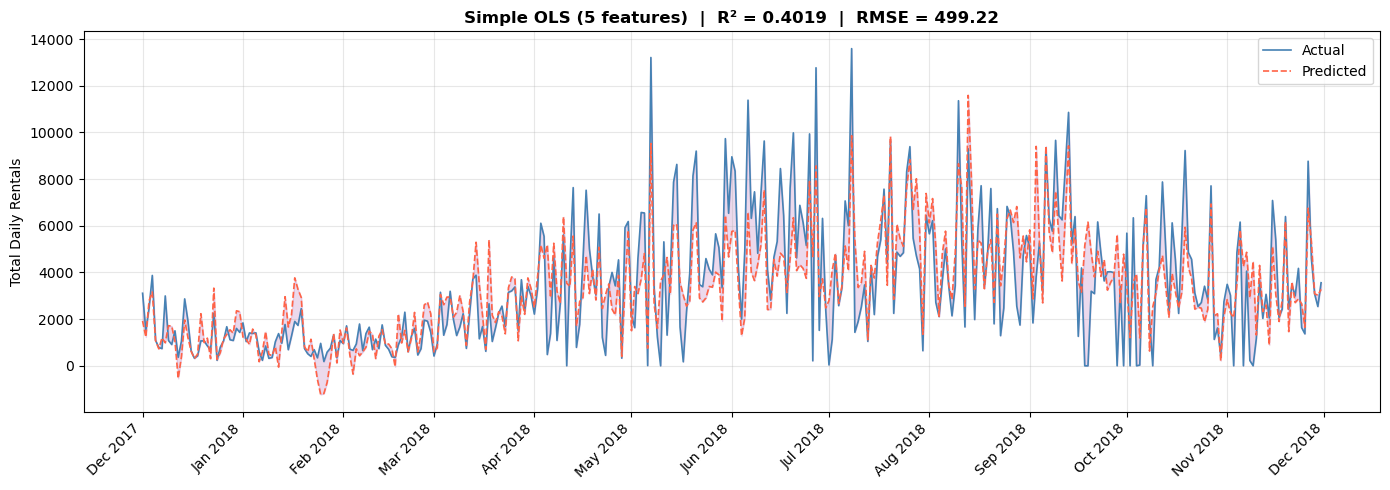

In [82]:
# Cell 1 — Simple OLS across date
plot_df = X_test.copy()
plot_df['Date']      = df.loc[X_test.index, 'Date']
plot_df['Actual']    = y_test.values
plot_df['Predicted'] = y_pred_simple.values

daily = (plot_df.groupby('Date')[['Actual', 'Predicted']]
                .sum().reset_index().sort_values('Date'))

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily['Date'], daily['Actual'],    color='steelblue', linewidth=1.2, label='Actual')
ax.plot(daily['Date'], daily['Predicted'], color='tomato', linewidth=1.2, linestyle='--', label='Predicted')
ax.fill_between(daily['Date'], daily['Actual'], daily['Predicted'], alpha=0.15, color='purple')
ax.set_title(f'Simple OLS (5 features)  |  R² = {r2_score(y_test, y_pred_simple):.4f}  |  RMSE = {np.sqrt(mean_squared_error(y_test, y_pred_simple)):.2f}', fontweight='bold')
ax.set_ylabel('Total Daily Rentals')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

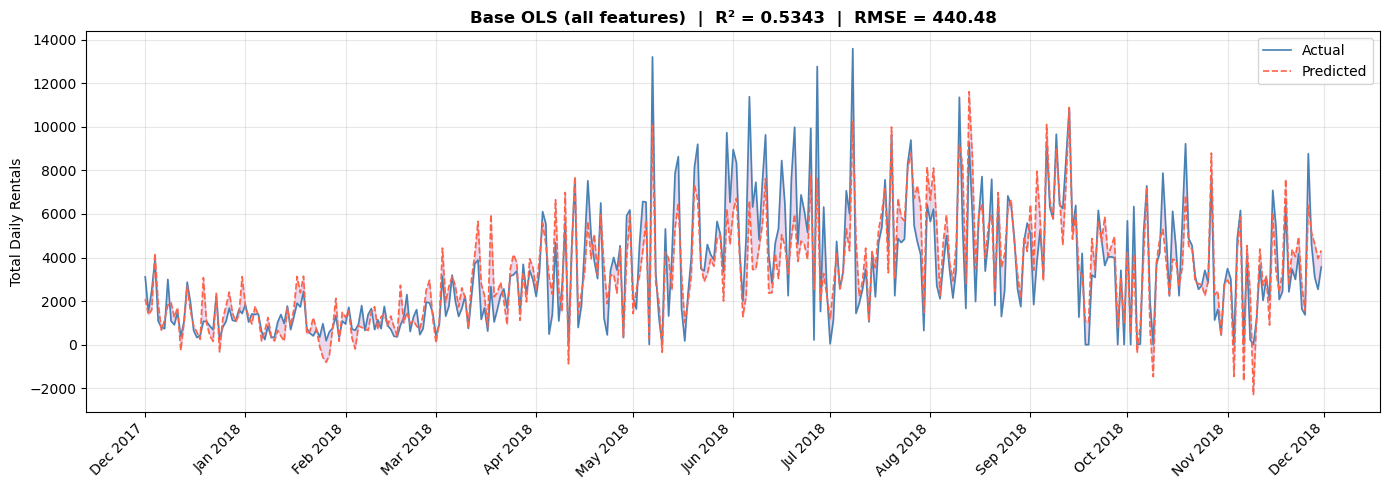

In [83]:
# Cell 2 — Base OLS across date
plot_df = X_test.copy()
plot_df['Date']      = df.loc[X_test.index, 'Date']
plot_df['Actual']    = y_test.values
plot_df['Predicted'] = y_pred_sm.values

daily = (plot_df.groupby('Date')[['Actual', 'Predicted']]
                .sum().reset_index().sort_values('Date'))

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily['Date'], daily['Actual'],    color='steelblue', linewidth=1.2, label='Actual')
ax.plot(daily['Date'], daily['Predicted'], color='tomato', linewidth=1.2, linestyle='--', label='Predicted')
ax.fill_between(daily['Date'], daily['Actual'], daily['Predicted'], alpha=0.15, color='purple')
ax.set_title(f'Base OLS (all features)  |  R² = {r2_score(y_test, y_pred_sm):.4f}  |  RMSE = {np.sqrt(mean_squared_error(y_test, y_pred_sm)):.2f}', fontweight='bold')
ax.set_ylabel('Total Daily Rentals')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

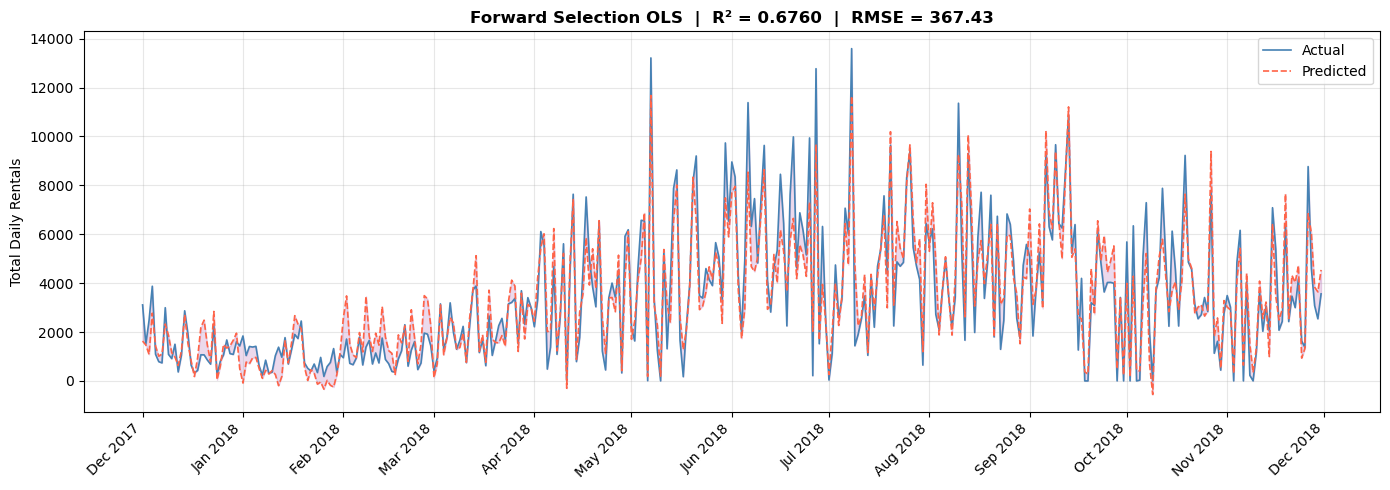

In [84]:
# Cell 3 — Forward Selection OLS across date
plot_df = X_test.copy()
plot_df['Date']      = df.loc[X_test.index, 'Date']
plot_df['Actual']    = y_test.values
plot_df['Predicted'] = y_pred_fwd.values

daily = (plot_df.groupby('Date')[['Actual', 'Predicted']]
                .sum().reset_index().sort_values('Date'))

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily['Date'], daily['Actual'],    color='steelblue', linewidth=1.2, label='Actual')
ax.plot(daily['Date'], daily['Predicted'], color='tomato', linewidth=1.2, linestyle='--', label='Predicted')
ax.fill_between(daily['Date'], daily['Actual'], daily['Predicted'], alpha=0.15, color='purple')
ax.set_title(f'Forward Selection OLS  |  R² = {r2_score(y_test, y_pred_fwd):.4f}  |  RMSE = {np.sqrt(mean_squared_error(y_test, y_pred_fwd)):.2f}', fontweight='bold')
ax.set_ylabel('Total Daily Rentals')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

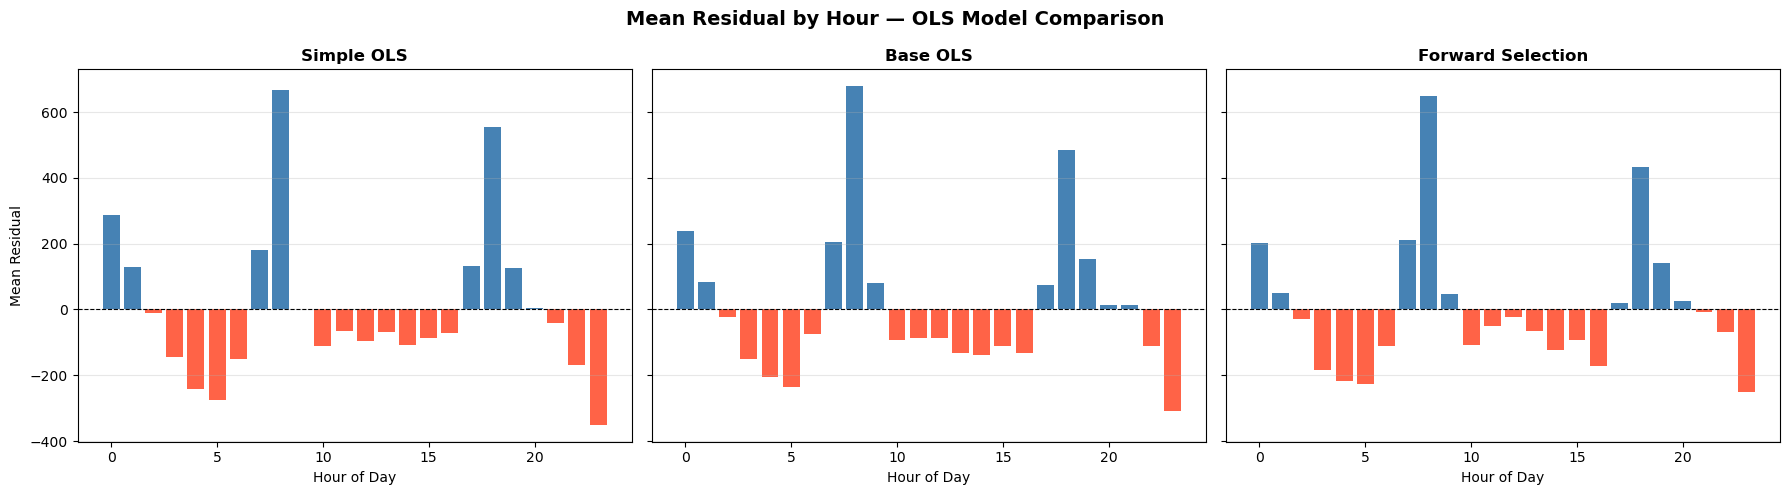

In [85]:
# Cell 1 — Residuals vs Hour for all three models
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

models = [
    ('Simple OLS',          y_pred_simple),
    ('Base OLS',            y_pred_sm),
    ('Forward Selection',   y_pred_fwd),
]

for ax, (title, y_pred) in zip(axes, models):
    resid_df = pd.DataFrame({
        'Hour':     X_test['Hour'].values,
        'Residual': (y_test.values - y_pred.values)
    })
    binned = resid_df.groupby('Hour')['Residual'].mean()

    ax.bar(binned.index, binned.values,
           color=['tomato' if r < 0 else 'steelblue' for r in binned.values])
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel('Hour of Day')
    ax.set_ylabel('Mean Residual' if ax == axes[0] else '')
    ax.set_title(title, fontweight='bold')
    ax.grid(alpha=0.3, axis='y')

plt.suptitle('Mean Residual by Hour — OLS Model Comparison',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

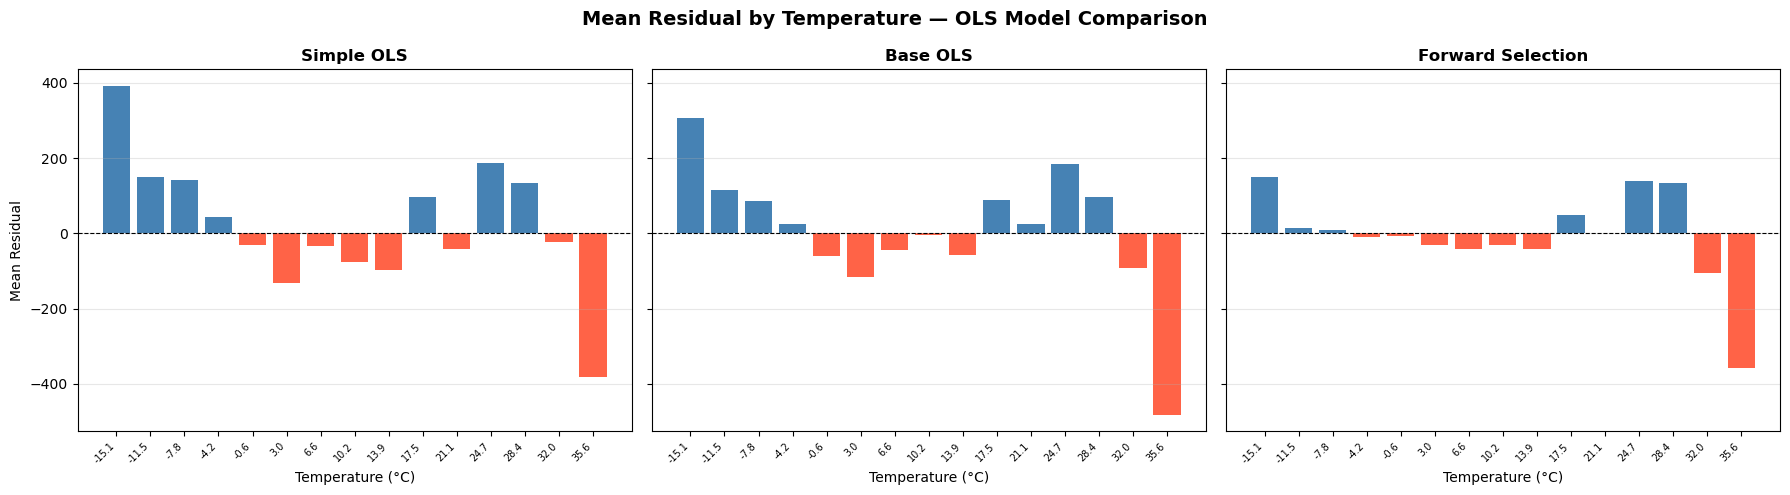

In [86]:
# Cell 2 — Residuals vs Temperature for all three models
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, (title, y_pred) in zip(axes, models):
    resid_df = pd.DataFrame({
        'Temperature': X_test['Temperature(°C)'].values,
        'Residual':    (y_test.values - y_pred.values)
    })
    resid_df['Temp_bin'] = pd.cut(resid_df['Temperature'], bins=15)
    binned = resid_df.groupby('Temp_bin', observed=True)['Residual'].mean()

    ax.bar(range(len(binned)), binned.values,
           color=['tomato' if r < 0 else 'steelblue' for r in binned.values])
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xticks(range(len(binned)))
    ax.set_xticklabels([f'{b.mid:.1f}' for b in binned.index],
                       rotation=45, ha='right', fontsize=7)
    ax.set_xlabel('Temperature (°C)')
    ax.set_ylabel('Mean Residual' if ax == axes[0] else '')
    ax.set_title(title, fontweight='bold')
    ax.grid(alpha=0.3, axis='y')

plt.suptitle('Mean Residual by Temperature — OLS Model Comparison',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

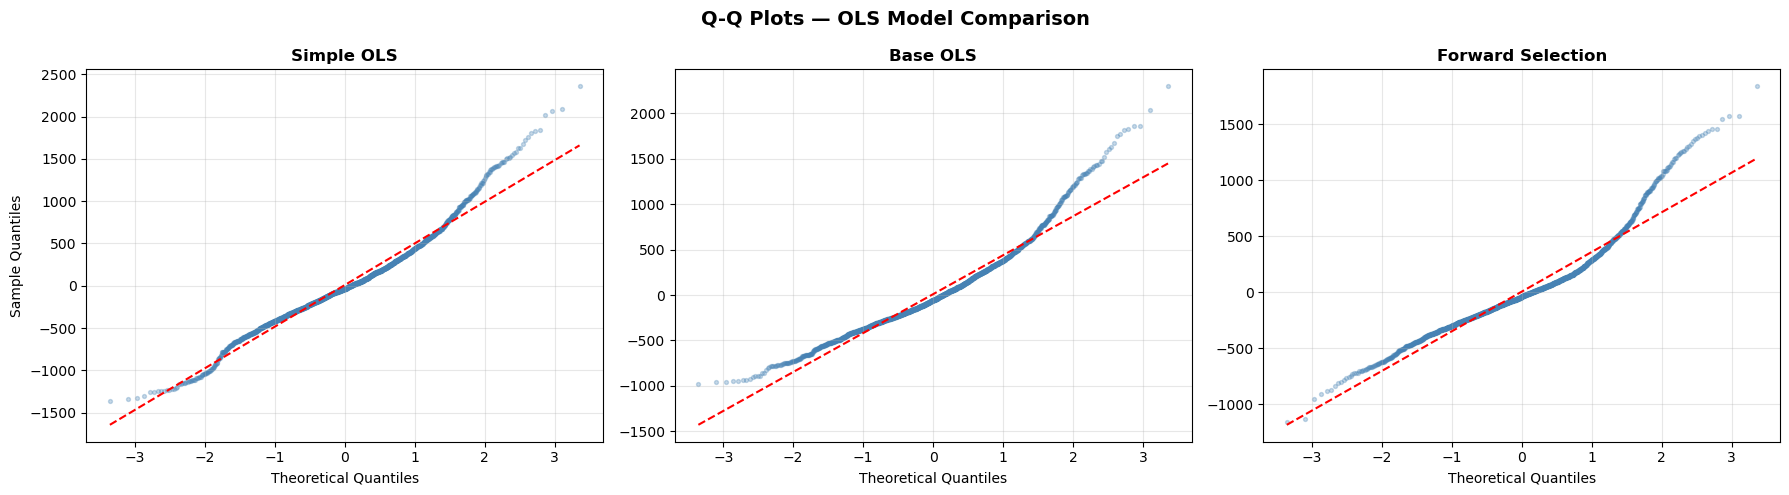

In [87]:
# Cell 3 — Q-Q plots for all three models
from scipy import stats

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (title, y_pred) in zip(axes, models):
    residuals = y_test.values - y_pred.values
    (osm, osr), (slope, intercept, r) = stats.probplot(residuals, dist='norm')

    ax.scatter(osm, osr, alpha=0.3, color='steelblue', s=8)
    ax.plot(osm, slope * np.array(osm) + intercept, 'r--', linewidth=1.5)
    ax.set_xlabel('Theoretical Quantiles')
    ax.set_ylabel('Sample Quantiles' if ax == axes[0] else '')
    ax.set_title(title, fontweight='bold')
    ax.grid(alpha=0.3)

plt.suptitle('Q-Q Plots — OLS Model Comparison',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

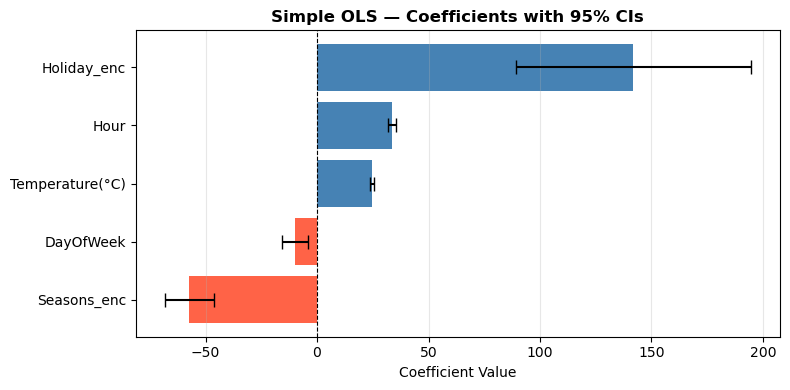

In [88]:
# Cell 1 — Simple OLS coefficients with 95% CIs
ci = ols_simple.conf_int()
coef_df = pd.DataFrame({
    'Coefficient': ols_simple.params,
    'lower':       ci[0],
    'upper':       ci[1]
}).drop('const').sort_values('Coefficient')

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(coef_df.index, coef_df['Coefficient'],
        xerr=[coef_df['Coefficient'] - coef_df['lower'],
              coef_df['upper'] - coef_df['Coefficient']],
        color=['tomato' if c < 0 else 'steelblue' for c in coef_df['Coefficient']],
        capsize=5)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Coefficient Value')
ax.set_title('Simple OLS — Coefficients with 95% CIs', fontweight='bold')
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

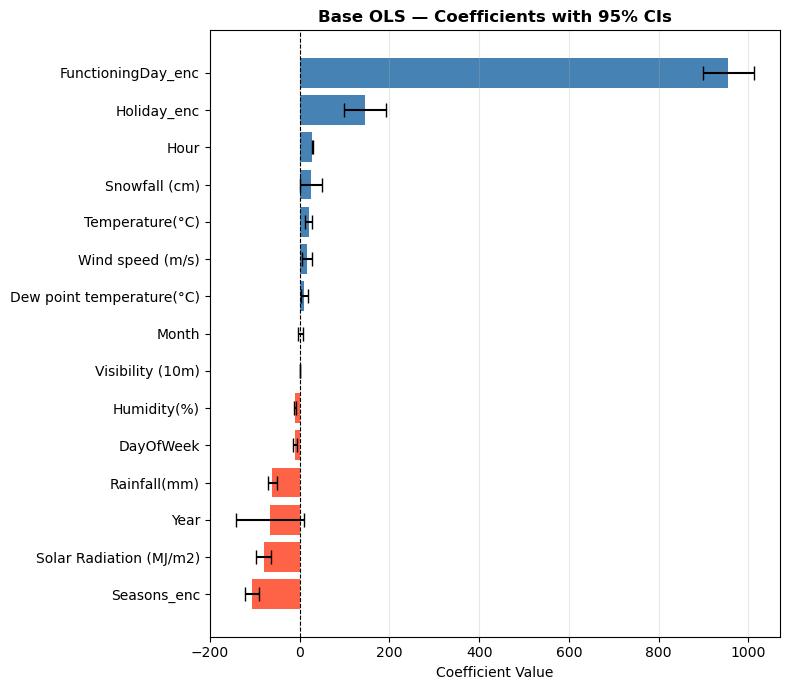

In [89]:
# Cell 2 — Base OLS coefficients with 95% CIs
ci = ols_model.conf_int()
coef_df = pd.DataFrame({
    'Coefficient': ols_model.params,
    'lower':       ci[0],
    'upper':       ci[1]
}).drop('const').sort_values('Coefficient')

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(coef_df.index, coef_df['Coefficient'],
        xerr=[coef_df['Coefficient'] - coef_df['lower'],
              coef_df['upper'] - coef_df['Coefficient']],
        color=['tomato' if c < 0 else 'steelblue' for c in coef_df['Coefficient']],
        capsize=5)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Coefficient Value')
ax.set_title('Base OLS — Coefficients with 95% CIs', fontweight='bold')
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

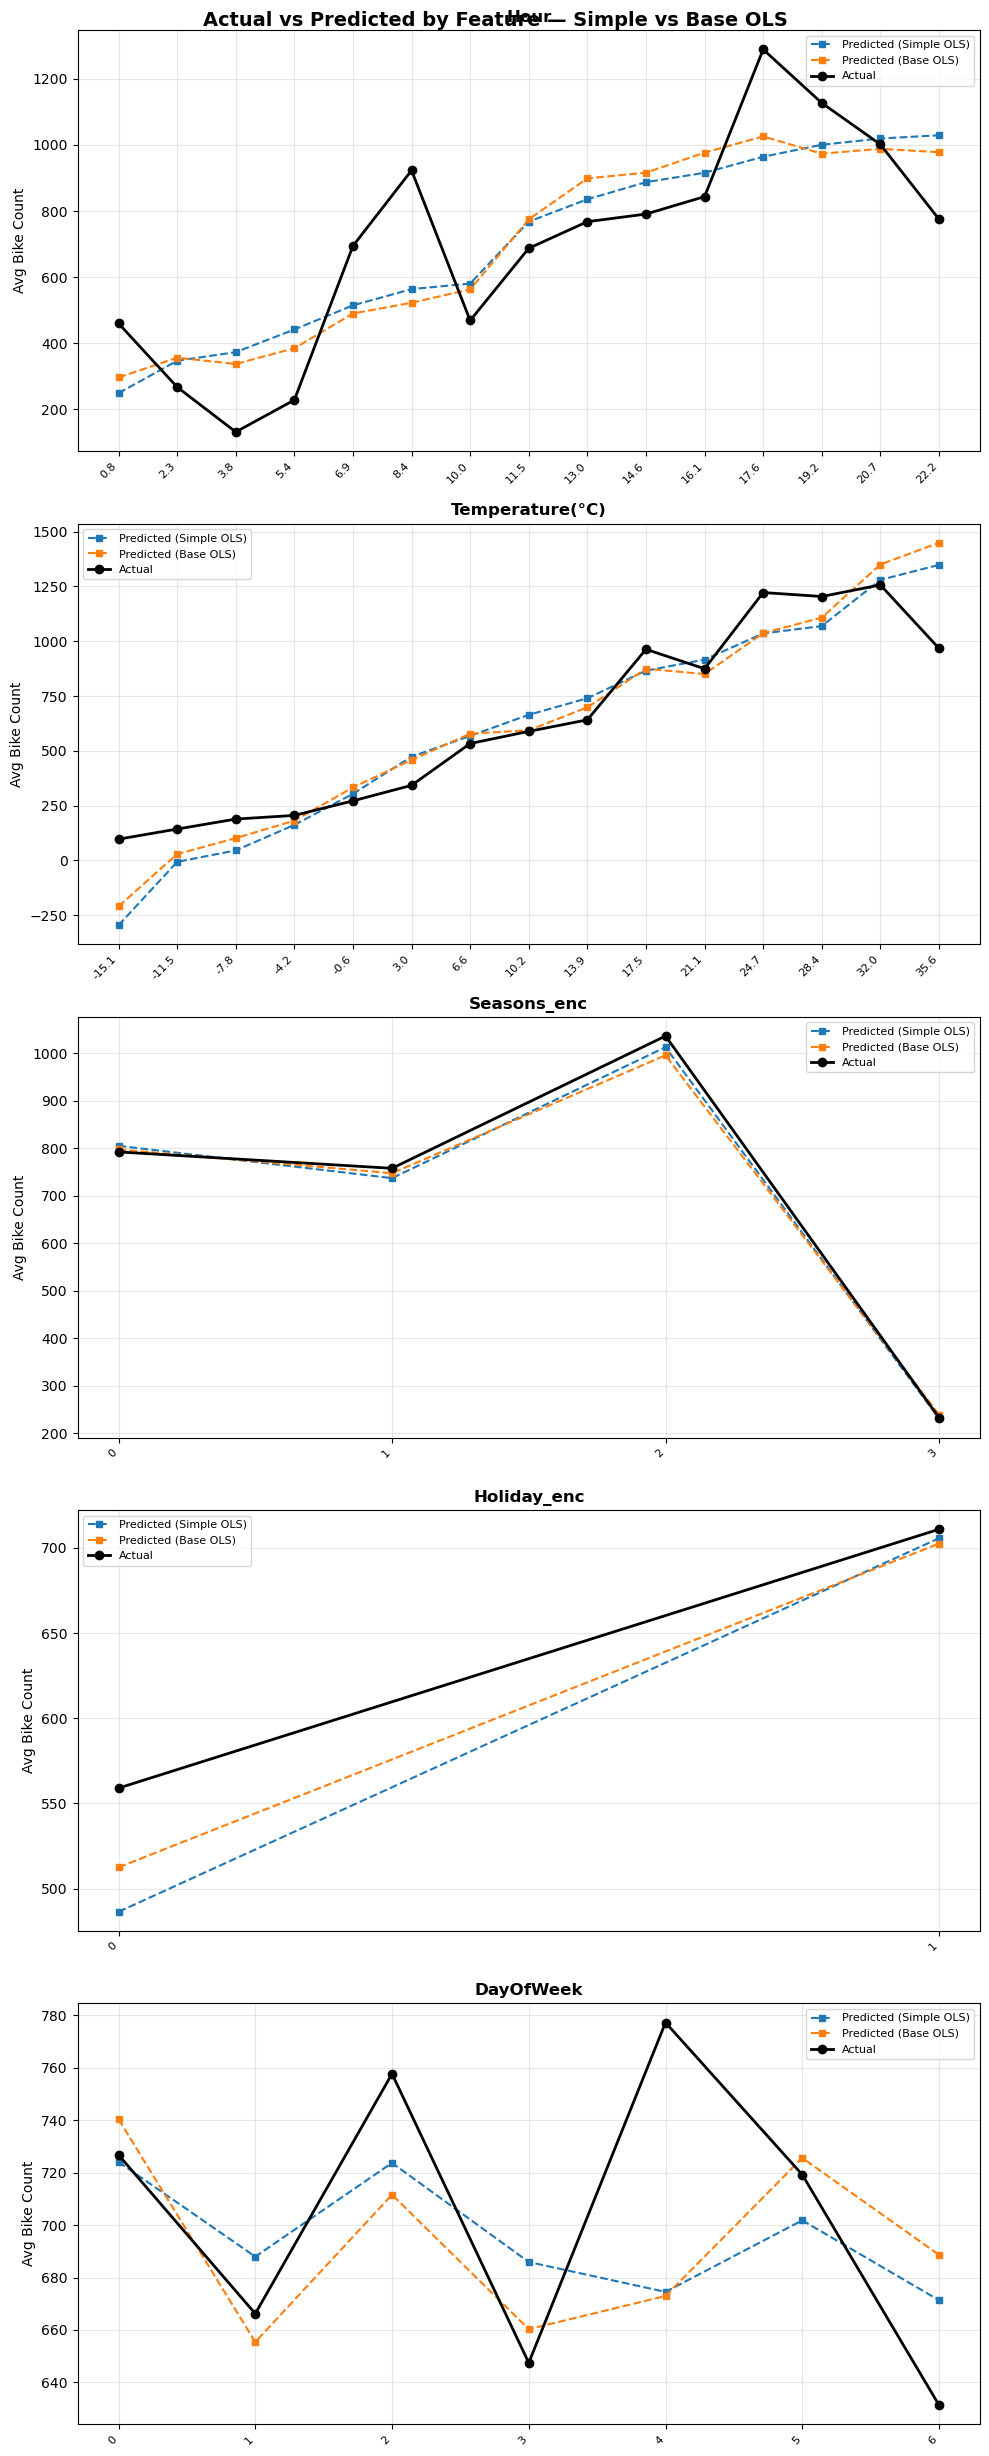

In [90]:
# Cell 1 — Actual vs Predicted binned by each of the 5 shared features
shared_features = ['Hour', 'Temperature(°C)', 'Seasons_enc', 'Holiday_enc', 'DayOfWeek']

models = [
    ('Simple OLS',        y_pred_simple),
    ('Base OLS',          y_pred_sm),
]

fig, axes = plt.subplots(len(shared_features), 1, figsize=(10, 25))

for ax, feat in zip(axes, shared_features):
    n_unique = X_test[feat].nunique()

    for title, y_pred in models:
        plot_df = X_test.copy()
        plot_df['Actual']    = y_test.values
        plot_df['Predicted'] = y_pred.values

        if n_unique > 15:
            plot_df['_bin'] = pd.cut(plot_df[feat], bins=15)
        else:
            plot_df['_bin'] = plot_df[feat]

        binned = (plot_df.groupby('_bin', observed=True)[['Actual', 'Predicted']]
                         .mean().reset_index().sort_values('_bin'))

        labels = [f'{b.mid:.1f}' if hasattr(b, 'mid') else str(b)
                  for b in binned['_bin']]

        ax.plot(range(len(binned)), binned['Predicted'], marker='s',
                linestyle='--', linewidth=1.5, markersize=5, label=f'Predicted ({title})')

    # Plot actual once (same for both models)
    ax.plot(range(len(binned)), binned['Actual'], marker='o',
            linestyle='-', linewidth=2, markersize=6,
            color='black', label='Actual')

    ax.set_xticks(range(len(binned)))
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
    ax.set_title(feat, fontweight='bold')
    ax.set_ylabel('Avg Bike Count')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Actual vs Predicted by Feature — Simple vs Base OLS',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

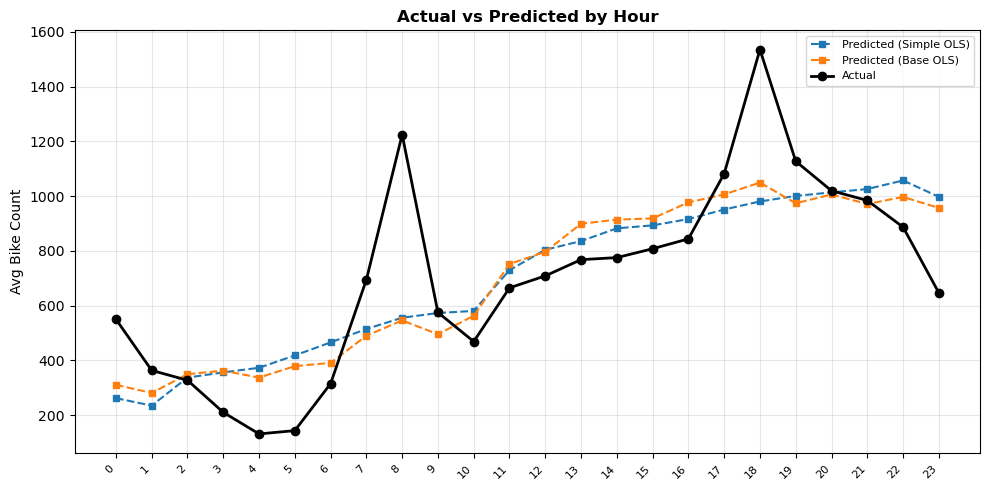

In [92]:
# Cell 1 — Hour
feat = 'Hour'
n_unique = X_test[feat].nunique()

fig, ax = plt.subplots(figsize=(10, 5))
for title, y_pred in models:
    plot_df = X_test.copy()
    plot_df['Actual']    = y_test.values
    plot_df['Predicted'] = y_pred.values
    plot_df['_bin']      = plot_df[feat]
    binned = (plot_df.groupby('_bin', observed=True)[['Actual', 'Predicted']]
                     .mean().reset_index().sort_values('_bin'))
    ax.plot(range(len(binned)), binned['Predicted'], marker='s',
            linestyle='--', linewidth=1.5, markersize=5, label=f'Predicted ({title})')

ax.plot(range(len(binned)), binned['Actual'], marker='o', linestyle='-',
        linewidth=2, markersize=6, color='black', label='Actual')
ax.set_xticks(range(len(binned)))
ax.set_xticklabels(binned['_bin'], rotation=45, ha='right', fontsize=8)
ax.set_title('Actual vs Predicted by Hour', fontweight='bold')
ax.set_ylabel('Avg Bike Count'); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

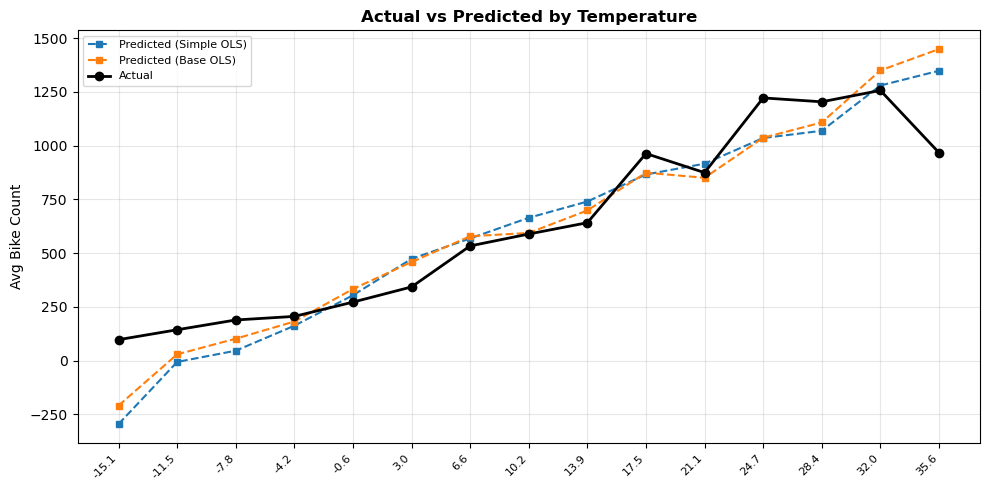

In [93]:
# Cell 2 — Temperature
feat = 'Temperature(°C)'

fig, ax = plt.subplots(figsize=(10, 5))
for title, y_pred in models:
    plot_df = X_test.copy()
    plot_df['Actual']    = y_test.values
    plot_df['Predicted'] = y_pred.values
    plot_df['_bin']      = pd.cut(plot_df[feat], bins=15)
    binned = (plot_df.groupby('_bin', observed=True)[['Actual', 'Predicted']]
                     .mean().reset_index().sort_values('_bin'))
    ax.plot(range(len(binned)), binned['Predicted'], marker='s',
            linestyle='--', linewidth=1.5, markersize=5, label=f'Predicted ({title})')

ax.plot(range(len(binned)), binned['Actual'], marker='o', linestyle='-',
        linewidth=2, markersize=6, color='black', label='Actual')
ax.set_xticks(range(len(binned)))
ax.set_xticklabels([f'{b.mid:.1f}' for b in binned['_bin']], rotation=45, ha='right', fontsize=8)
ax.set_title('Actual vs Predicted by Temperature', fontweight='bold')
ax.set_ylabel('Avg Bike Count'); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

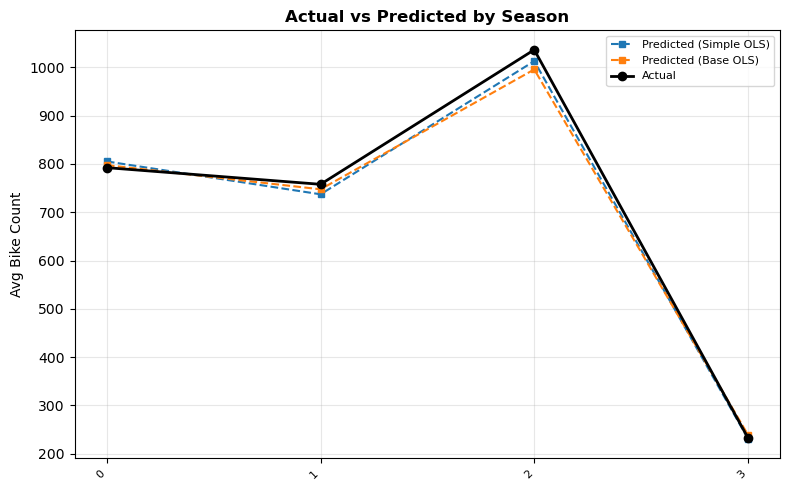

In [94]:
# Cell 3 — Seasons
feat = 'Seasons_enc'

fig, ax = plt.subplots(figsize=(8, 5))
for title, y_pred in models:
    plot_df = X_test.copy()
    plot_df['Actual']    = y_test.values
    plot_df['Predicted'] = y_pred.values
    plot_df['_bin']      = plot_df[feat]
    binned = (plot_df.groupby('_bin', observed=True)[['Actual', 'Predicted']]
                     .mean().reset_index().sort_values('_bin'))
    ax.plot(range(len(binned)), binned['Predicted'], marker='s',
            linestyle='--', linewidth=1.5, markersize=5, label=f'Predicted ({title})')

ax.plot(range(len(binned)), binned['Actual'], marker='o', linestyle='-',
        linewidth=2, markersize=6, color='black', label='Actual')
ax.set_xticks(range(len(binned)))
ax.set_xticklabels(binned['_bin'], rotation=45, ha='right', fontsize=8)
ax.set_title('Actual vs Predicted by Season', fontweight='bold')
ax.set_ylabel('Avg Bike Count'); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

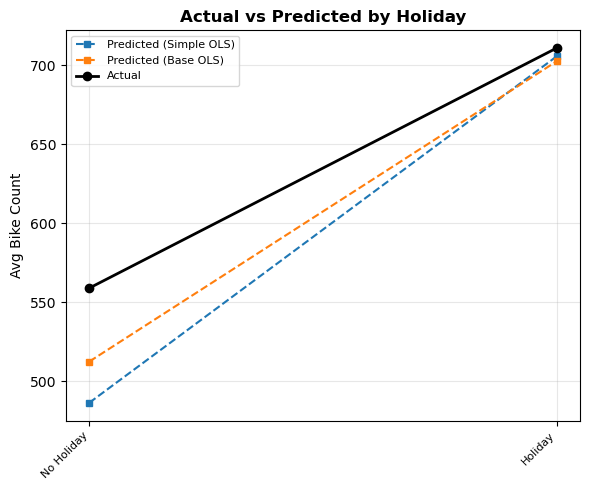

In [95]:
# Cell 4 — Holiday
feat = 'Holiday_enc'

fig, ax = plt.subplots(figsize=(6, 5))
for title, y_pred in models:
    plot_df = X_test.copy()
    plot_df['Actual']    = y_test.values
    plot_df['Predicted'] = y_pred.values
    plot_df['_bin']      = plot_df[feat]
    binned = (plot_df.groupby('_bin', observed=True)[['Actual', 'Predicted']]
                     .mean().reset_index().sort_values('_bin'))
    ax.plot(range(len(binned)), binned['Predicted'], marker='s',
            linestyle='--', linewidth=1.5, markersize=5, label=f'Predicted ({title})')

ax.plot(range(len(binned)), binned['Actual'], marker='o', linestyle='-',
        linewidth=2, markersize=6, color='black', label='Actual')
ax.set_xticks(range(len(binned)))
ax.set_xticklabels(['No Holiday', 'Holiday'], rotation=45, ha='right', fontsize=8)
ax.set_title('Actual vs Predicted by Holiday', fontweight='bold')
ax.set_ylabel('Avg Bike Count'); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

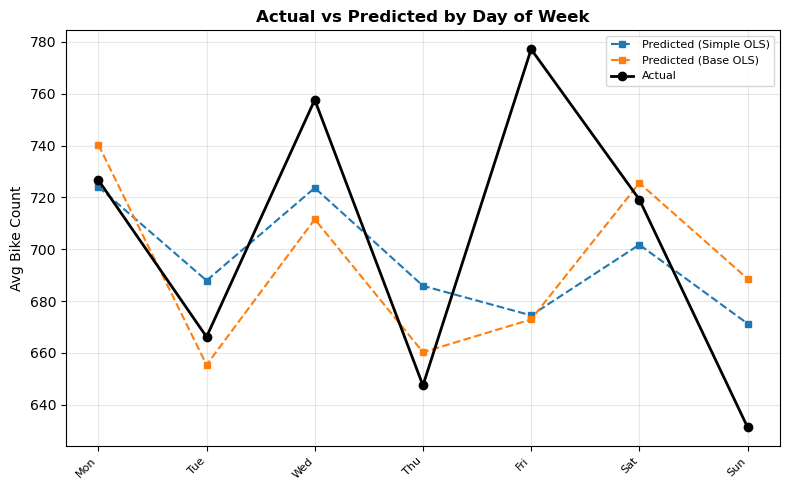

In [96]:
# Cell 5 — DayOfWeek
feat = 'DayOfWeek'

fig, ax = plt.subplots(figsize=(8, 5))
for title, y_pred in models:
    plot_df = X_test.copy()
    plot_df['Actual']    = y_test.values
    plot_df['Predicted'] = y_pred.values
    plot_df['_bin']      = plot_df[feat]
    binned = (plot_df.groupby('_bin', observed=True)[['Actual', 'Predicted']]
                     .mean().reset_index().sort_values('_bin'))
    ax.plot(range(len(binned)), binned['Predicted'], marker='s',
            linestyle='--', linewidth=1.5, markersize=5, label=f'Predicted ({title})')

ax.plot(range(len(binned)), binned['Actual'], marker='o', linestyle='-',
        linewidth=2, markersize=6, color='black', label='Actual')
ax.set_xticks(range(len(binned)))
ax.set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'],
                   rotation=45, ha='right', fontsize=8)
ax.set_title('Actual vs Predicted by Day of Week', fontweight='bold')
ax.set_ylabel('Avg Bike Count'); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 3. Generalised Linear Model

### Why OLS is Insufficient

OLS assumes the response variable is normally distributed with constant variance.
However, **Rented Bike Count** is a non-negative integer — a count variable — which
violates these assumptions. The Q-Q plots confirm this, showing heavy tails and 
systematic deviation from normality across all linear models fitted.

### Proposed GLM: Poisson Regression

The natural choice for count data is a **Poisson GLM**, defined by:

$$Y_i \sim \text{Poisson}(\mu_i)$$

$$\log(\mu_i) = \beta_0 + \beta_1 X_{i1} + \beta_2 X_{i2} + \cdots + \beta_p X_{ip}$$

where:
- $Y_i$ is the observed bike count for observation $i$
- $\mu_i = E(Y_i)$ is the expected count
- $\log(\cdot)$ is the **canonical link function** for the Poisson family
- $\beta_0, \beta_1, \ldots, \beta_p$ are the model coefficients

This can be equivalently written as:

$$\mu_i = \exp(\beta_0 + \beta_1 X_{i1} + \cdots + \beta_p X_{ip})$$

which **guarantees non-negative predictions** — a property OLS cannot ensure.

### Why Poisson?

The Poisson distribution assumes:

$$P(Y_i = y) = \frac{e^{-\mu_i} \mu_i^y}{y!}, \quad y = 0, 1, 2, \ldots$$

with the key property that $E(Y_i) = \text{Var}(Y_i) = \mu_i$ (mean equals variance).

This is appropriate here because:
- Bike rentals are **non-negative counts**
- The **log link** is interpretable — coefficients represent log incidence rate ratios
- It naturally handles the **right-skewed** distribution of rental counts

### Potential Limitation: Overdispersion

If $\text{Var}(Y_i) > E(Y_i)$ (overdispersion), the Poisson assumption is violated.
This can be tested after fitting via the **dispersion statistic**:

$$\hat{\phi} = \frac{\sum_{i=1}^n (y_i - \hat{\mu}_i)^2 / \hat{\mu}_i}{n - p}$$

If $\hat{\phi} \gg 1$, a **Negative Binomial GLM** is preferred, which introduces an
additional dispersion parameter $r$ to model excess variance:

$$\text{Var}(Y_i) = \mu_i + \frac{\mu_i^2}{r}$$

### Coefficient Interpretation

Unlike OLS where $\beta_j$ represents an additive unit change in $Y$, in a Poisson GLM:

$$\frac{\partial \log(\mu_i)}{\partial X_{ij}} = \beta_j$$

meaning a one-unit increase in $X_j$ **multiplies** the expected count by $e^{\beta_j}$.
For example, if $\beta_{\text{temp}} = 0.03$, then a 1°C increase in temperature
is associated with a $e^{0.03} \approx 1.03$ times — or **3% increase** — in expected rentals.

The natural choice for count data is a Poisson GLM, defined by:

$$Y_i \sim \text{Poisson}(\mu_i)$$

$$\log(\mu_i) = \beta_0 + \beta_1 X_{i1} + \beta_2 X_{i2} + \cdots + \beta_p X_{ip}$$

where $Y_i$ is the observed bike count for observation $i$, $\mu_i = E(Y_i)$ is the
expected count, and $\beta_0, \beta_1, \ldots, \beta_p$ are the model coefficients.
This can be equivalently written as:

$$\mu_i = \exp(\beta_0 + \beta_1 X_{i1} + \cdots + \beta_p X_{ip})$$

The NB2 model arises as a Poisson-Gamma mixture. Conditional on a latent rate
$\lambda_i$, the observed count follows a Poisson distribution:

$$Y_i \mid \lambda_i \sim \text{Poisson}(\lambda_i)$$


$$\lambda_i \sim \text{Gamma}\left(\mu_i, k\right)$$



with mean and variance:

$$E(Y_i) = \mu_i, \qquad \text{Var}(Y_i) = \mu_i + \frac{1}{k}\mu_i^2$$

and log link:

$$\log(\mu_i) = \beta_0 + \beta_1 X_{i1} + \cdots + \beta_p X_{ip}$$

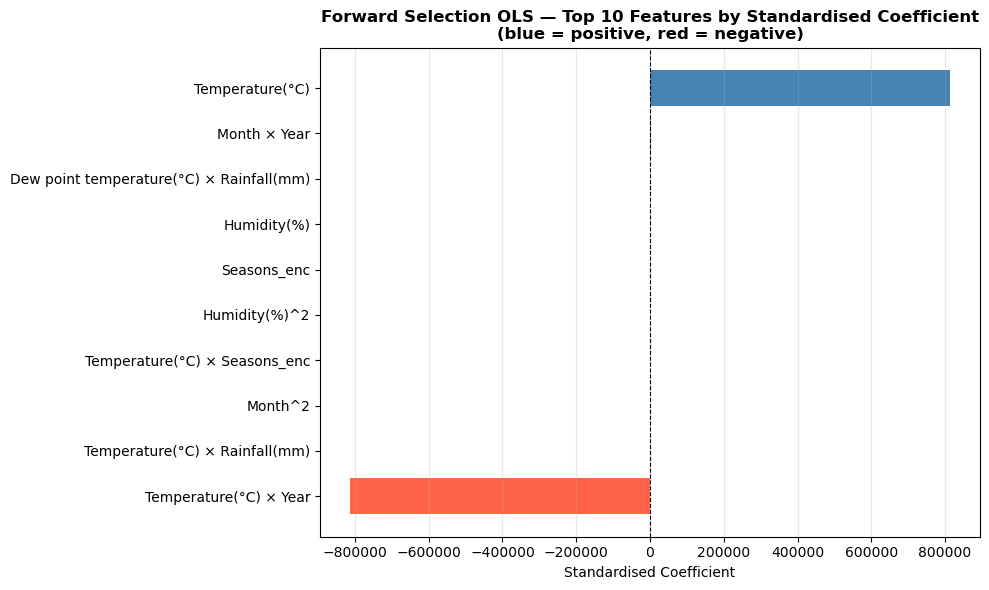

In [101]:
# Cell 1 — Standardised coefficients for Forward Selection OLS
from sklearn.preprocessing import StandardScaler

# Get the features used in the forward selection model (excluding const)
fwd_features = [f for f in ols_fwd_model.params.index if f != 'const']

# Standardise the test features
scaler = StandardScaler()
X_train_fwd_feats = X_train_int[fwd_features]
scaler.fit(X_train_fwd_feats)

# Standardised coefficients = coef * std of each feature
std_coefs = pd.Series(
    ols_fwd_model.params[fwd_features].values * scaler.scale_,
    index=fwd_features
)

top10_std = std_coefs.reindex(std_coefs.abs()
                                       .sort_values(ascending=False)
                                       .head(10).index)
top10_std = top10_std.sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top10_std.index, top10_std.values,
        color=['tomato' if c < 0 else 'steelblue' for c in top10_std.values])
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Standardised Coefficient')
ax.set_title('Forward Selection OLS — Top 10 Features by Standardised Coefficient\n(blue = positive, red = negative)',
             fontweight='bold')
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

In [102]:
# Cell 1 — Rank features by partial R²
import statsmodels.api as sm

fwd_features = [f for f in ols_fwd_model.params.index if f != 'const']

partial_r2 = {}
# R² of the full model
r2_full = ols_fwd_model.rsquared

for feat in fwd_features:
    # Refit without this feature
    remaining = [f for f in fwd_features if f != feat]
    model_reduced = sm.OLS(y_train, sm.add_constant(X_train_int[remaining])).fit()
    # Partial R² = how much R² drops when feature is removed
    partial_r2[feat] = r2_full - model_reduced.rsquared

partial_r2_series = pd.Series(partial_r2).sort_values(ascending=False)

print("Top 10 features by partial R²:")
print(partial_r2_series.head(10))

Top 10 features by partial R²:
Hour × Temperature(°C)                                 0.026305
Month^2                                                0.014293
Month × Year                                           0.013612
Month × Seasons_enc                                    0.010623
Humidity(%)                                            0.009232
Humidity(%)^2                                          0.008858
Dew point temperature(°C) × Solar Radiation (MJ/m2)    0.007257
Hour × Humidity(%)                                     0.006416
Humidity(%) × Solar Radiation (MJ/m2)                  0.005673
Hour × FunctioningDay_enc                              0.005538
dtype: float64


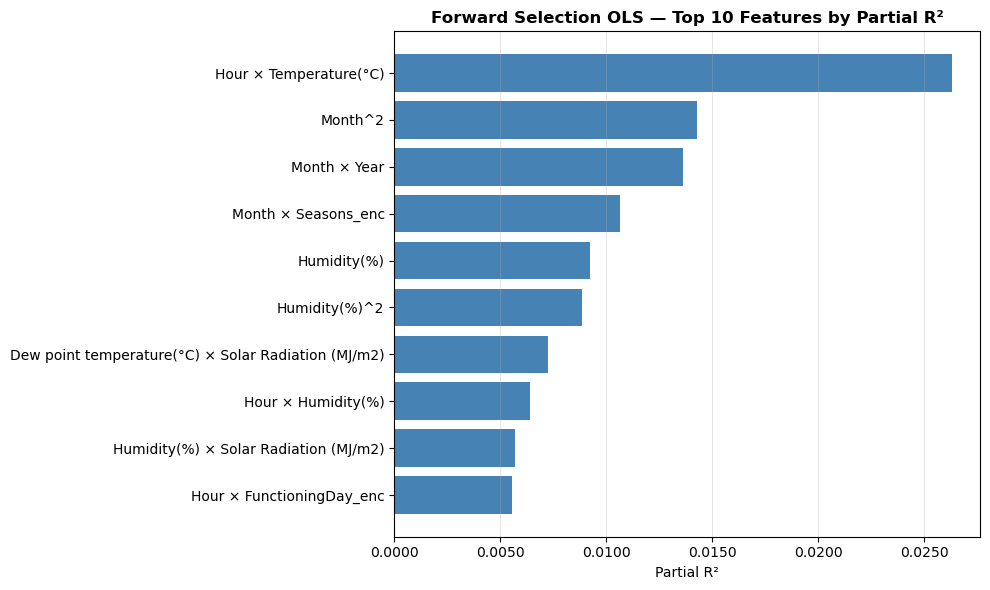

In [104]:
# Cell 2 — Plot top 10 by partial R²
top10_pr2 = partial_r2_series.head(10).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top10_pr2.index, top10_pr2.values, color='steelblue')
ax.set_xlabel('Partial R²')
ax.set_title('Forward Selection OLS — Top 10 Features by Partial R²',
             fontweight='bold')
ax.grid(alpha=0.3, axis='x')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.4f}'))
plt.tight_layout()
plt.show()